In [1]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from collections import Counter
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import norm, t
from scipy.stats import expon
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot,show,title ,xlabel,ylabel
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep
from scipy.stats import chi2
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import LeavePOut
from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV
import psutil
import glob
import pyarrow as pa
import pyarrow.parquet as pq
import os

In [ ]:

def csv_to_parquet_optimized(csv_file, parquet_file):

    print(f"\nProcessing: {csv_file}")

    # Read CSV
    df = pd.read_csv(
        csv_file,
        low_memory=False
    )

    # Memory BEFORE
    memory_before = (
        df.memory_usage(deep=True)
        .sum()
        / 1024**2
    )

    # -------------------------
    # Downcasting
    # -------------------------

    # Integer columns
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(
            df[col],
            downcast='integer'
        )

    # Float columns
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(
            df[col],
            downcast='float'
        )

    # Object columns
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype('category')

    # Memory AFTER
    memory_after = (
        df.memory_usage(deep=True)
        .sum()
        / 1024**2
    )

    # Save Parquet
    df.to_parquet(
        parquet_file,
        index=False
    )

    parquet_size = (
        os.path.getsize(parquet_file)
        / 1024**2
    )

    reduction = (
        (memory_before - memory_after)
        / memory_before
    ) * 100

    print(f"Memory Before : {memory_before:.2f} MB")
    print(f"Memory After  : {memory_after:.2f} MB")
    print(f"Reduction     : {reduction:.2f}%")
    print(f"Parquet Size  : {parquet_size:.2f} MB")

    return df

In [ ]:
csv_to_parquet_optimized(
    "/content/drive/MyDrive/Case_study/loans_master.csv",
    "/content/drive/MyDrive/Case_study/loans.parquet"
)


Processing: /content/drive/MyDrive/Case_study/loans_master.csv
Memory Before : 1564.73 MB
Memory After  : 310.57 MB
Reduction     : 80.15%
Parquet Size  : 78.31 MB


,loan_id,issue_date,issue_year,issue_month,loan_amnt_inr,funded_amnt_inr,loan_term_months,int_rate_pct,installment_inr,annual_installment_inr,...,pymnt_plan,hardship_flag,initial_list_status,disbursement_method,verification_status,rbi_repo_rate_pct,gdp_growth_pct,cpi_inflation_pct,rate_spread_pct,real_interest_rate_pct
0,LN000000001,Feb-2016,2016,2,80678.0,74992.0,36,14.910000,2793.17,33518.0,...,N,N,w,DIRECT_PAY,Source Verified,6.25,8.2,4.5,8.660000,10.410000
1,LN000000002,May-2024,2024,5,274166.0,265041.0,36,7.000000,8465.45,101585.0,...,N,N,w,CASH,Verified,6.50,6.8,4.9,0.500000,2.100000
2,LN000000003,Dec-2021,2021,12,59603.0,54423.0,60,13.340000,1366.55,16399.0,...,N,N,w,DIRECT_PAY,Source Verified,4.00,8.7,5.1,9.340000,8.240000
3,LN000000004,Nov-2020,2020,11,246313.0,224181.0,84,24.070000,6088.88,73067.0,...,N,N,w,DIRECT_PAY,Source Verified,4.00,-6.6,6.2,20.070000,17.870001
4,LN000000005,Jul-2013,2013,7,101471.0,95361.0,60,8.520000,2082.81,24994.0,...,Y,N,w,CASH,Verified,7.75,6.4,10.9,0.770000,-2.380000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,LN001999996,Oct-2018,2018,10,85677.0,80974.0,48,21.559999,2678.92,32147.0,...,N,N,w,DIRECT_PAY,Source Verified,6.50,6.1,3.4,15.060000,18.160000
1999996,LN001999997,Apr-2023,2023,4,72216.0,72064.0,36,17.969999,2609.69,31316.0,...,N,N,w,CASH,Not Verified,6.50,7.6,5.4,11.470000,12.570000
1999997,LN001999998,Oct-2021,2021,10,52596.0,47050.0,60,12.320000,1178.49,14142.0,...,N,N,w,CASH,Source Verified,4.00,8.7,5.1,8.320000,7.220000
1999998,LN001999999,Feb-2016,2016,2,97617.0,87171.0,48,7.000000,2337.56,28051.0,...,N,Y,w,CASH,Source Verified,6.25,8.2,4.5,0.750000,2.500000


In [ ]:
csv_to_parquet_optimized(
    "/content/drive/MyDrive/Case_study/customer_bureau.csv",
    "/content/drive/MyDrive/Case_study/customer_bureau.parquet"
)



Processing: /content/drive/MyDrive/Case_study/customer_bureau.csv
Memory Before : 1014.09 MB
Memory After  : 482.87 MB
Reduction     : 52.38%
Parquet Size  : 119.55 MB


,loan_id,customer_id,age,gender,emp_title,emp_length_years,home_ownership,annual_inc_inr,dti_pct,cibil_score,...,num_inq_last12m,pct_tl_nvr_dlq,total_rev_hi_lim_inr,bc_util_pct,il_util_pct,all_util_pct,avg_cur_bal_inr,mths_since_last_delinq,mths_since_last_record,num_tl_op_past_12m
0,LN000000001,CU01240276,45,M,Salaried,0.0,RENT,133866.0,14.990000,624,...,7.0,65.400002,763.84,25.900000,75.900002,43.099998,1112.97,NaN,NaN,3
1,LN000000002,CU01359733,40,M,Salaried,1.7,MORTGAGE,909588.0,6.730000,840,...,4.0,81.800003,67523.72,75.900002,67.199997,64.400002,183.81,17.0,NaN,2
2,LN000000003,CU01350772,35,M,Salaried,11.3,OWN,140046.0,24.650000,642,...,4.0,84.500000,16570.17,38.700001,40.000000,28.299999,1084.46,3.0,169.0,3
3,LN000000004,CU00064269,44,M,Salaried,2.4,MORTGAGE,265704.0,33.480000,826,...,0.0,89.400002,66114.89,51.000000,79.599998,63.200001,2479.75,15.0,NaN,7
4,LN000000005,CU01193840,64,F,Retired,4.7,RENT,1529175.0,18.059999,635,...,3.0,88.400002,8649.19,NaN,39.099998,19.400000,440.61,13.0,15.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,LN001999996,CU01264653,26,M,Salaried,NaN,MORTGAGE,1176192.0,17.940001,638,...,7.0,66.500000,53787.16,30.500000,30.299999,39.299999,399.89,7.0,NaN,9
1999996,LN001999997,CU01075962,55,M,Retired,1.0,RENT,451011.0,25.340000,696,...,1.0,62.299999,47957.50,64.400002,37.200001,37.400002,4350.50,8.0,42.0,1
1999997,LN001999998,CU00471323,55,F,Salaried,3.9,RENT,356639.0,24.270000,800,...,6.0,75.800003,84722.92,54.099998,37.099998,18.900000,846.07,5.0,NaN,7
1999998,LN001999999,CU00845459,53,M,Other,NaN,MORTGAGE,347550.0,15.490000,632,...,6.0,77.500000,579.97,46.000000,77.000000,53.900002,53.23,NaN,NaN,7


In [ ]:
csv_to_parquet_optimized(
    "/content/drive/MyDrive/Case_study/payment_history.csv",
    "/content/drive/MyDrive/Case_study/payment_history.parquet"
)



Processing: /content/drive/MyDrive/Case_study/payment_history.csv
Memory Before : 373.84 MB
Memory After  : 371.58 MB
Reduction     : 0.60%
Parquet Size  : 87.10 MB


,loan_id,loan_status,lgd_pct,total_pymnt_inr,total_pymnt_inv_inr,total_rec_prncp_inr,total_rec_int_inr,last_pymnt_amnt_inr,out_prncp_inr,out_prncp_inv_inr,collection_recovery_fee,collections_12mths_fee,mths_since_last_pymnt,num_accts_ever_120_pd,num_derog_rec,acc_now_delinq,chargeoff_within_12_mths,expected_loss_inr
0,LN000000001,0,0.000000,102327.83,98339.43,80678.00,21649.83,13922.84,0.00,0.00,0.00,0.00,1,0,0,0,0.00,0.00
1,LN000000002,0,0.000000,319635.13,309461.58,274166.00,45469.13,22957.63,0.00,0.00,0.00,0.00,1,0,1,0,0.00,0.00
2,LN000000003,0,0.000000,79687.39,78661.62,59603.00,20084.39,NaN,0.00,0.00,0.00,0.00,1,0,0,0,0.00,0.00
3,LN000000004,0,0.000000,509995.37,492937.00,246313.00,263682.37,13529.63,0.00,0.00,0.00,0.00,2,0,0,0,0.00,0.00
4,LN000000005,0,0.000000,126155.61,126048.04,101471.00,24684.61,9962.35,0.00,0.00,0.00,0.00,2,0,0,0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,LN001999996,0,0.000000,128534.23,122763.06,85677.00,42857.23,14758.62,0.00,0.00,0.00,0.00,0,0,1,0,0.00,0.00
1999996,LN001999997,0,0.000000,96161.50,92539.68,72216.00,23945.50,1034.32,0.00,0.00,0.00,0.00,1,0,0,0,0.00,0.00
1999997,LN001999998,1,39.279999,5934.24,5785.85,5934.24,0.00,NaN,46661.76,45922.71,971.09,35.39,27,2,1,0,20659.71,747.73
1999998,LN001999999,0,0.000000,114863.84,112499.03,97617.00,17246.84,5109.31,0.00,0.00,0.00,0.00,0,0,0,0,0.00,0.00


In [ ]:
csv_to_parquet_optimized(
    "/content/drive/MyDrive/Case_study/loan_performance.csv",
    "/content/drive/MyDrive/Case_study/loan_performance.parquet"
)


Processing: /content/drive/MyDrive/Case_study/loan_performance.csv
Memory Before : 558.29 MB
Memory After  : 266.68 MB
Reduction     : 52.23%
Parquet Size  : 38.45 MB


,loan_id,dpd_bucket,npa_flag,risk_tier,cibil_score_band,recoveries_inr,recovery_fee_rate,policy_code,hardship_amount_inr,hardship_length_mths,net_loss_inr,provision_inr
0,LN000000001,Current,0,Medium Risk,Poor,0.00,0.000,1,0.00,0,0.0,397.93
1,LN000000002,Current,0,Low Risk,Excellent,0.00,0.000,1,11568.37,9,0.0,304.07
2,LN000000003,Current,0,Medium Risk,Poor,0.00,0.000,1,0.00,0,0.0,483.40
3,LN000000004,Current,0,High Risk,Excellent,0.00,0.000,1,0.00,0,0.0,4730.75
4,LN000000005,Current,0,Low Risk,Poor,0.00,0.000,1,0.00,0,0.0,379.61
...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,LN001999996,Current,0,High Risk,Poor,0.00,0.000,1,0.00,0,0.0,1067.66
1999996,LN001999997,Current,0,High Risk,Fair,0.00,0.000,1,0.00,0,0.0,770.62
1999997,LN001999998,1-30 DPD,0,Medium Risk,Excellent,4365.71,0.214,1,0.00,0,16294.0,254.78
1999998,LN001999999,Current,0,Low Risk,Poor,0.00,0.000,1,0.00,0,0.0,223.71


In [ ]:
csv_to_parquet_optimized(
    "/content/drive/MyDrive/Case_study/loan_enquiry_bureau.csv",
    "/content/drive/MyDrive/Case_study/loan_enquiry_bureau.parquet"
)


Processing: /content/drive/MyDrive/Case_study/loan_enquiry_bureau.csv
Memory Before : 1109.23 MB
Memory After  : 255.25 MB
Reduction     : 76.99%
Parquet Size  : 55.03 MB


,loan_id,num_enquiries_30d,num_enquiries_90d,num_enquiries_6m,num_enquiries_12m,num_enquiries_24m,primary_enq_purpose,unique_lenders_enquired,rejected_applications,approved_applications,...,credit_committee_flag,loan_approved_date,processing_days,sourcing_channel,sourcing_agent_type,policy_deviation_flag,policy_override_flag,sanctioned_amount_inr,disbursed_amount_inr,tat_within_sla_flag
0,LN000000001,0,3,5,8,16,Personal Loan,3,0,8,...,0,Jan-2016,17.0,Branch,Online,0,0,74537.0,73139.0,0
1,LN000000002,5,8,9,9,9,Personal Loan,1,1,8,...,0,Oct-2024,4.0,Bancassurance,Bank Staff,1,0,266436.0,256842.0,1
2,LN000000003,1,2,6,12,21,Personal Loan,4,1,11,...,0,Feb-2021,12.0,Branch,DSA Partner,0,0,59049.0,57544.0,0
3,LN000000004,0,2,5,8,9,Business Loan,6,0,8,...,1,Nov-2020,11.0,Branch,Online,1,0,227840.0,216791.0,0
4,LN000000005,1,1,2,2,3,Vehicle Loan,2,0,2,...,0,Sep-2013,7.0,DSA,DSA Partner,0,0,99065.0,92233.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,LN001999996,0,0,5,5,8,Business Loan,5,0,5,...,1,Mar-2018,20.0,Branch,Bank Staff,1,0,78728.0,76608.0,0
1999996,LN001999997,0,1,2,6,14,Home Loan,5,0,6,...,1,Dec-2023,NaN,Bancassurance,Bank Staff,1,0,65295.0,64400.0,0
1999997,LN001999998,0,0,4,7,12,Personal Loan,5,1,6,...,0,Apr-2021,12.0,Branch,Aggregator,0,0,47920.0,46820.0,0
1999998,LN001999999,1,3,5,9,11,Business Loan,3,1,8,...,0,Mar-2016,NaN,Bancassurance,Direct,0,0,84140.0,79698.0,1


In [ ]:
csv_to_parquet_optimized(
    "/content/drive/MyDrive/Case_study/credit_card_behavior.csv",
    "/content/drive/MyDrive/Case_study/credit_card_behavior.parquet"
)




Processing: /content/drive/MyDrive/Case_study/credit_card_behavior.csv
Memory Before : 587.13 MB
Memory After  : 262.87 MB
Reduction     : 55.23%
Parquet Size  : 59.11 MB


,loan_id,has_credit_card,num_credit_cards,total_cc_limit_inr,total_cc_balance_inr,cc_utilization_pct,cc_late_payments_count,cc_overlimit_count,cash_advance_inr,primary_card_type,primary_cc_bank,cc_spend_last3m_inr,avg_monthly_cc_spend_inr,top_spend_category,cc_payment_score,cc_default_risk_score,cc_emi_conversion_flag
0,LN000000001,1,2,74592.0,39358.0,52.799999,0,0,0.0,Basic,SBI,14230.0,4743.0,Online,100.0,0.2640,0
1,LN000000002,1,4,448024.0,97640.0,21.799999,3,0,0.0,Basic,SBI,122785.0,40928.0,Retail,85.0,0.1715,0
2,LN000000003,1,2,75123.0,44687.0,59.500000,0,0,NaN,Silver,Axis,17153.0,5718.0,Fuel,NaN,0.2975,0
3,LN000000004,0,0,0.0,0.0,0.000000,0,0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,0.0000,0
4,LN000000005,1,1,749805.0,369674.0,49.299999,2,0,0.0,Silver,ICICI,186364.0,62121.0,Fuel,90.0,0.2882,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,LN001999996,1,1,510035.0,193032.0,37.799999,0,0,0.0,Silver,Axis,168678.0,56226.0,Retail,NaN,0.1890,0
1999996,LN001999997,1,1,106793.0,19753.0,18.500000,3,2,3633.0,Basic,SCB,33738.0,11246.0,Retail,NaN,0.1550,0
1999997,LN001999998,1,2,88945.0,21909.0,24.600000,7,1,0.0,Silver,SBI,28788.0,9596.0,Travel,NaN,0.2688,0
1999998,LN001999999,1,3,171301.0,75738.0,44.200001,0,0,NaN,Silver,SBI,56500.0,18833.0,Retail,100.0,0.2210,0


In [ ]:
csv_to_parquet_optimized(
    "/content/drive/MyDrive/Case_study/collateral_assets.csv",
    "/content/drive/MyDrive/Case_study/collateral_assets.parquet"
)


Processing: /content/drive/MyDrive/Case_study/collateral_assets.csv
Memory Before : 844.51 MB
Memory After  : 276.23 MB
Reduction     : 67.29%
Parquet Size  : 44.83 MB


,loan_id,has_collateral,collateral_type,collateral_value_inr,ltv_ratio_pct,loan_secured_flag,property_type,property_age_years,property_area_sqft,property_city_tier,vehicle_type,vehicle_age_years,insurance_flag,valuation_date,valuation_agency,charge_type,collateral_score,prop_value_inr,vehicle_value_inr,business_asset_val_inr
0,LN000000001,0,NaN,0.0,NaN,0,NaN,0,0,NaN,NaN,0,0,May-2016,NaN,NaN,0.000000,0.0,0.0,0.0
1,LN000000002,1,Business Assets,607261.0,45.150002,1,NaN,0,0,NaN,NaN,0,1,Jul-2023,JLL,First Charge,72.000000,0.0,0.0,607261.0
2,LN000000003,1,Property,4194101.0,1.420000,1,Residential,20,3094,Tier1,NaN,0,0,Oct-2021,Cushman,Equitable Mortgage,48.099998,4194101.0,0.0,0.0
3,LN000000004,1,Property,3462228.0,NaN,1,Residential,26,4869,Tier2,NaN,0,1,Mar-2020,ICRA,First Charge,NaN,3462228.0,0.0,0.0
4,LN000000005,0,NaN,0.0,NaN,0,NaN,0,0,NaN,NaN,0,0,Feb-2012,NaN,NaN,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,LN001999996,1,Property,1720035.0,4.980000,1,Residential,24,2464,Tier2,NaN,0,1,Oct-2018,NaN,First Charge,67.599998,1720035.0,0.0,0.0
1999996,LN001999997,0,NaN,0.0,NaN,0,NaN,0,0,NaN,NaN,0,0,May-2022,NaN,NaN,0.000000,0.0,0.0,0.0
1999997,LN001999998,1,Vehicle,379098.0,NaN,1,NaN,0,0,NaN,Car,11,1,Dec-2020,JLL,First Charge,72.599998,0.0,379098.0,0.0
1999998,LN001999999,1,Property,4094516.0,2.380000,1,Residential,23,3297,Tier1,NaN,0,0,Nov-2016,Cushman,Equitable Mortgage,59.700001,4094516.0,0.0,0.0


In [ ]:
csv_to_parquet_optimized(
    "/content/drive/MyDrive/Case_study/branch_region_economy.csv",
    "/content/drive/MyDrive/Case_study/branch_region_economy.parquet"
)


Processing: /content/drive/MyDrive/Case_study/branch_region_economy.csv
Memory Before : 664.13 MB
Memory After  : 292.06 MB
Reduction     : 56.02%
Parquet Size  : 53.41 MB


,loan_id,branch_id,district_type,state_per_capita_inc_inr,state_literacy_rate_pct,state_agri_share_pct,state_industry_share_pct,state_services_share_pct,district_gdp_growth_pct,branch_age_years,branch_size,loan_officer_exp_years,branch_npa_rate,branch_sanction_rate,infrastructure_index,financial_inclusion_idx,credit_penetration_idx,covid_issue_year_flag,poor_monsoon_year_flag
0,LN000000001,BR6893-OR,Urban,78000,72.900002,28,30,42,7.25,26,Small,5.0,0.0536,0.769,18.100000,0.700,0.540,0,1
1,LN000000002,BR4150-JH,Semi-Urban,72000,66.400002,26,32,42,6.94,12,Small,6.2,0.0764,0.712,29.100000,0.740,0.651,0,1
2,LN000000003,BR4542-TN,Semi-Urban,220000,80.099998,10,34,56,7.02,21,Large,10.9,0.0181,0.575,54.500000,0.825,0.598,0,0
3,LN000000004,BR4994-RJ,Urban,100000,66.099998,24,28,48,5.88,23,Medium,30.0,0.0353,0.862,23.000000,0.675,0.584,1,1
4,LN000000005,BR2488-DL,Urban,390000,86.300003,1,18,81,8.61,22,Medium,3.9,0.0281,0.805,92.300003,0.651,0.549,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,LN001999996,BR9976-DL,Urban,390000,86.300003,1,18,81,7.78,6,Medium,3.6,0.0323,0.783,97.000000,0.637,0.470,0,1
1999996,LN001999997,BR1538-OR,Rural,78000,72.900002,28,30,42,6.52,27,Large,1.0,0.0445,0.754,18.000000,0.627,0.579,0,1
1999997,LN001999998,BR9195-GJ,Urban,200000,78.000000,16,42,42,7.53,25,Large,1.0,0.0604,0.771,49.000000,0.676,0.492,0,0
1999998,LN001999999,BR4525-MP,Semi-Urban,85000,69.300003,30,24,46,5.49,26,Medium,2.9,0.0287,0.861,21.799999,0.511,0.405,0,1


In [ ]:
csv_to_parquet_optimized(
    "/content/drive/MyDrive/Case_study/monthly_emi_track.csv",
    "/content/drive/MyDrive/Case_study/monthly_emi_track.parquet"
)


Processing: /content/drive/MyDrive/Case_study/monthly_emi_track.csv
Memory Before : 808.17 MB
Memory After  : 346.80 MB
Reduction     : 57.09%
Parquet Size  : 89.13 MB


,loan_id,installment_due_inr,total_emi_due_inr,total_emi_paid_inr,emi_overdue_inr,emi_bounce_count,consecutive_missed_emis,last_emi_payment_date,emi_advance_paid_inr,prepayment_flag,...,penal_charges_inr,waiver_granted_flag,waiver_amount_inr,loan_restructured_flag,ots_offered_flag,ots_accepted_flag,emi_coverage_ratio,pdc_count,emi_to_income_ratio,payment_discipline
0,LN000000001,2793.17,100554.12,103925.57,0.00,0,0,Oct-2019,0.00,0,...,0.00,0,0.0,0,0,0,3.990000,6.0,0.2504,Excellent
1,LN000000002,8465.45,304756.20,308223.00,0.00,1,0,May-2024,0.00,0,...,1488.08,0,0.0,0,0,0,8.950000,6.0,0.1117,Good
2,LN000000003,1366.55,81993.00,83657.21,0.00,1,0,Sep-2022,0.00,0,...,932.45,0,0.0,0,0,0,8.540000,3.0,0.1171,Good
3,LN000000004,6088.88,511465.92,496707.66,14758.26,1,0,Jan-2023,0.00,0,...,807.41,0,0.0,0,0,0,3.640000,2.0,0.2750,Good
4,LN000000005,2082.81,124968.60,120842.83,4125.77,0,0,May-2017,0.00,0,...,0.00,0,0.0,0,0,0,61.180000,2.0,0.0163,Excellent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,LN001999996,2678.92,128588.16,125190.92,3397.24,0,0,Oct-2020,2574.28,1,...,0.00,0,0.0,0,0,0,36.590000,3.0,0.0273,Excellent
1999996,LN001999997,2609.69,93948.84,92583.68,1365.16,0,0,Jul-2024,0.00,0,...,0.00,0,0.0,0,0,0,14.400000,6.0,0.0694,Excellent
1999997,LN001999998,1178.49,70709.40,49968.43,20740.97,9,16,Jul-2022,0.00,0,...,8219.30,0,0.0,1,0,0,25.219999,12.0,0.0397,Poor
1999998,LN001999999,2337.56,112202.88,107978.24,4224.64,3,0,Jul-2019,0.00,0,...,3369.32,0,0.0,0,0,0,12.390000,0.0,0.0807,Fair


loading the parquate files

In [ ]:
parquet_files = {
    "loans":"loans.parquet",
    "customer":"customer_bureau.parquet",
    "payment":"payment_history.parquet",
    "performance":"loan_performance.parquet",
    "enquiry":"loan_enquiry_bureau.parquet",
    "credit":"credit_card_behavior.parquet",
    "collateral":"collateral_assets.parquet",
    "branch":"branch_region_economy.parquet",
    "emi":"monthly_emi_track.parquet"
}

dic = {}

for name,file in parquet_files.items():
    dic[name] = pd.read_parquet(
        f"/content/drive/MyDrive/Case_study/{file}"
    )

In [ ]:
for name,df in dic.items():

    print("\n",name)

    print("Rows:",len(df))

    print("Unique Loan IDs:",
          df.loan_id.nunique())

    print("Duplicate Loan IDs:",
          df.loan_id.duplicated().sum())


 loans
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 customer
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 payment
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 performance
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 enquiry
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 credit
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 collateral
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 branch
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 emi
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0


1B)

In [ ]:
base_df = dic["loans"].copy()

print("Initial Rows:", len(base_df))

Initial Rows: 2000000


merging the loan and with customer

In [ ]:
base_df = base_df.merge(
    dic["customer"],
    on="loan_id",
    how="left"
)

assert len(base_df) == 2000000

print("After customer merge:", len(base_df))

After customer merge: 2000000


Merge Payment

In [ ]:
base_df = base_df.merge(
    dic["payment"],
    on="loan_id",
    how="left"
)

assert len(base_df) == 2000000

print("After payment merge:", len(base_df))

After payment merge: 2000000


Merge Performance

In [ ]:
base_df = base_df.merge(
    dic["performance"],
    on="loan_id",
    how="left"
)

assert len(base_df) == 2000000
print("after performance merge:",len(base_df))

after performance merge: 2000000


Merge Enquiry

In [ ]:
base_df = base_df.merge(
    dic["enquiry"],
    on="loan_id",
    how="left"
)

assert len(base_df) == 2000000
print("after enquiry merge:",len(base_df))

after enquiry merge: 2000000


Merge Credit

In [ ]:
base_df = base_df.merge(
    dic["credit"],
    on="loan_id",
    how="left"
)

assert len(base_df) == 2000000
print("after credit merge:",len(base_df))

after credit merge: 2000000


Merge Collateral

In [ ]:
base_df = base_df.merge(
    dic["collateral"],
    on="loan_id",
    how="left"
)

assert len(base_df) == 2000000
print("after collateral merge:",len(base_df))

after collateral merge: 2000000


Merge Branch

In [ ]:
base_df = base_df.merge(
    dic["branch"],
    on="loan_id",
    how="left"
)

assert len(base_df) == 2000000
print("after branch merge:",len(base_df))

after branch merge: 2000000


Merge EMI

In [ ]:
base_df = base_df.merge(
    dic["emi"],
    on="loan_id",
    how="left"
)

assert len(base_df) == 2000000
print("after EMI merge:",len(base_df))

after EMI merge: 2000000


Orphan Record Calculation

In [ ]:
for name in [
    "customer",
    "payment",
    "performance",
    "enquiry",
    "credit",
    "collateral",
    "branch",
    "emi"
]:

    orphan_count = (
        ~dic[name]["loan_id"]
        .isin(dic["loans"]["loan_id"])
    ).sum()

    print(f"{name}: {orphan_count}")

customer: 0
payment: 0
performance: 0
enquiry: 0
credit: 0
collateral: 0
branch: 0
emi: 0


In [ ]:
base_df.to_parquet(
    "/content/drive/MyDrive/Case_study/finsight_merged.parquet",
    index=False
)

1C)

In [ ]:
base_df.shape
base_df.info()
base_df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Columns: 193 entries, loan_id to payment_discipline
dtypes: category(48), float32(56), float64(33), int16(3), int32(1), int8(52)
memory usage: 1.3 GB


,count,mean,std,min,25%,50%,75%,max
issue_year,2000000.0,2017.929101,4.138790,2010.0000,2015.000,2018.0000,2022.000000,2.024000e+03
issue_month,2000000.0,6.500045,3.452964,1.0000,4.000,6.0000,10.000000,1.200000e+01
loan_amnt_inr,2000000.0,150338.859375,133503.718750,50000.0000,64541.000,109172.0000,184666.000000,5.000000e+06
funded_amnt_inr,2000000.0,141323.218750,125499.148438,44000.0000,60587.000,102546.0000,173600.000000,4.810737e+06
loan_term_months,2000000.0,45.129150,15.748448,12.0000,36.000,48.0000,60.000000,8.400000e+01
...,...,...,...,...,...,...,...,...
ots_offered_flag,2000000.0,0.003107,0.055654,0.0000,0.000,0.0000,0.000000,1.000000e+00
ots_accepted_flag,2000000.0,0.001734,0.041605,0.0000,0.000,0.0000,0.000000,1.000000e+00
emi_coverage_ratio,2000000.0,16.421827,24.347427,0.0300,4.120,8.8600,19.219999,2.049740e+03
pdc_count,1879943.0,3.519546,3.678178,0.0000,1.000,2.0000,6.000000,1.200000e+01


Q1(c) Dirty Data Detection

**Negative Income**

In [ ]:
base_df[base_df['annual_inc_inr'] < 0].shape

(0, 193)

CIBIL Less Than 300

In [ ]:
base_df[base_df['cibil_score'] < 300].shape

(0, 193)

CIBIL Greater Than 900

In [ ]:
base_df[base_df['cibil_score'] > 900].shape

(0, 193)

Negative Interest Rate

In [ ]:
base_df[base_df['int_rate_pct'] < 0].shape

(0, 193)

Interest Rate Above 100

In [ ]:
base_df[base_df['int_rate_pct'] > 100].shape

(0, 193)

Negative DTI

In [ ]:
base_df[base_df['dti_pct'] < 0].shape

(0, 193)

Revolving Utilization > 100

In [ ]:
base_df[base_df['revol_util_pct'] > 100].shape

(0, 193)

Negative Employment Length

In [ ]:
base_df[base_df['emp_length_years'] < 0].shape

(0, 193)

Age Less Than 18

In [ ]:
base_df[base_df['age'] < 18].shape

(0, 193)

Loan Amount <= 0

In [ ]:
base_df[base_df['loan_amnt_inr'] <= 0].shape

(0, 193)

Check Numeric Extremes

In [ ]:
numeric_cols = base_df.select_dtypes(
    include=['int8','int16','int32',
             'float32','float64']
).columns

summary = base_df[numeric_cols].describe().T

summary[
    ['min','max']
].sort_values('min').head(30)

,min,max
gdp_growth_pct,-6.6,8.700000e+00
real_interest_rate_pct,-3.9,2.460000e+01
rate_spread_pct,-1.0,2.400000e+01
emp_length_years,0.0,3.500000e+01
num_inq_last12m,0.0,1.400000e+01
bc_util_pct,0.0,9.960000e+01
delinq_2yrs,0.0,7.000000e+00
revol_util_pct,0.0,9.980000e+01
mort_acc,0.0,5.000000e+00
pub_rec,0.0,3.000000e+00


In [ ]:
summary[['min','max']] \
    .sort_values('max', ascending=False) \
    .head(30)

,min,max
collateral_value_inr,0.000,25572246.00
prop_value_inr,0.000,25572246.00
annual_inc_inr,100000.000,20000000.00
business_asset_val_inr,0.000,14841821.00
total_emi_due_inr,51916.080,7525000.80
total_emi_paid_inr,10764.920,7389451.25
total_pymnt_inr,2519.440,7242829.18
total_pymnt_inv_inr,2424.050,6885217.83
emi_advance_paid_inr,0.000,5329334.00
loan_amnt_inr,50000.000,5000000.00


In [3]:
import os

os.path.exists(
    "/content/drive/MyDrive/Case_study/finsight_merged.parquet"
)

True

In [4]:
import pandas as pd

base_df = pd.read_parquet(
    "/content/drive/MyDrive/Case_study/finsight_merged.parquet"
)

print(base_df.shape)

(2000000, 193)


In [5]:
base_df.to_parquet(
    "/content/drive/MyDrive/Case_study/finsight_merged.parquet",
    index=False
)

Find Missing Values

In [ ]:
missing_df = (
    base_df.isnull()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

missing_df.columns = ["Column","Missing_Count"]

missing_df["Missing_Percent"] = (
    missing_df["Missing_Count"]
    / len(base_df)
)*100

missing_df.head(50)

,Column,Missing_Count,Missing_Percent
0,vehicle_type,1879789,93.98945
1,property_type,1679672,83.98360
2,property_city_tier,1679672,83.98360
3,mths_since_last_record,1598332,79.91660
4,ltv_ratio_pct,1472196,73.60980
5,valuation_agency,1370048,68.50240
6,collateral_type,1258896,62.94480
7,charge_type,1258896,62.94480
8,mths_since_last_delinq,1098640,54.93200
9,primary_card_type,560528,28.02640


Checking Duplicates

In [ ]:
base_df.duplicated().sum()

np.int64(0)

checking the duplicate loan ids

In [ ]:
base_df["loan_id"].duplicated().sum()

np.int64(0)

finding suspicious columns

In [ ]:
base_df.select_dtypes(
    include=['object','category']
).nunique().sort_values()

,0
application_type,2
initial_list_status,2
hardship_flag,2
pymnt_plan,2
disbursement_method,2
verification_status,3
gender,3
home_ownership,3
field_verification_status,3
risk_tier_y,3


missing-value pattern for each high-missing column

In [ ]:
base_df[
[
    "mths_since_last_delinq",
    "mort_acc",
    "emp_length_years",
    "il_util_pct"
]
].isnull().sum()

,0
mths_since_last_delinq,1098640
mort_acc,260330
emp_length_years,180539
il_util_pct,200167


missing-value pattern for each high-missing column

In [ ]:
for col in [
    "cibil_score",
    "int_rate_pct",
    "dti_pct",
    "revol_util_pct",
    "bc_util_pct"
]:

    if col in base_df.columns:
        print("\n",col)
        print(base_df[col].describe())


 cibil_score
count    2.000000e+06
mean     6.798828e+02
std      8.462665e+01
min      3.000000e+02
25%      6.230000e+02
50%      6.800000e+02
75%      7.370000e+02
max      9.000000e+02
Name: cibil_score, dtype: float64

 int_rate_pct
count    2.000000e+06
mean     1.357475e+01
std      4.373115e+00
min      7.000000e+00
25%      1.012000e+01
50%      1.286000e+01
75%      1.649000e+01
max      2.800000e+01
Name: int_rate_pct, dtype: float64

 dti_pct
count    2.000000e+06
mean     1.715152e+01
std      9.575985e+00
min      1.000000e-02
25%      9.680000e+00
50%      1.587000e+01
75%      2.337000e+01
max      5.747000e+01
Name: dti_pct, dtype: float64

 revol_util_pct
count    1.859903e+06
mean     3.999655e+01
std      2.000164e+01
min      0.000000e+00
25%      2.430000e+01
50%      3.860000e+01
75%      5.440000e+01
max      9.980000e+01
Name: revol_util_pct, dtype: float64

 bc_util_pct
count    1.839603e+06
mean     3.998701e+01
std      1.998981e+01
min      0.000000e+00
25

imputing

In [ ]:
#mths_since_last_delinq
base_df['mths_since_last_delinq'] = (
    base_df['mths_since_last_delinq']
    .fillna(999)  #999 = No Delinquency History
)

In [ ]:
#mort_acc
base_df['mort_acc'] = (
    base_df['mort_acc']
    .fillna(
        base_df['mort_acc'].median()
    )
)

In [ ]:
#emp_length_years
base_df['emp_length_years'] = (
    base_df['emp_length_years']
    .fillna(
        base_df['emp_length_years'].median()
    )
)

In [ ]:
#il_util_pct
base_df['il_util_pct'] = (
    base_df['il_util_pct']
    .fillna(0)
)

In [ ]:
# after imputaion
base_df[
[
'mths_since_last_delinq',
'mort_acc',
'emp_length_years',
'il_util_pct'
]
].isnull().sum()

,0
mths_since_last_delinq,0
mort_acc,0
emp_length_years,0
il_util_pct,0


Dirty Flag

In [ ]:
dirty_columns = [
    'mths_since_last_delinq',
    'mort_acc',
    'emp_length_years',
    'il_util_pct',
    'bc_util_pct',
    'revol_util_pct',
    'collateral_score',
    'income_doc_type'
]

base_df['dirty_flag'] = (
    base_df[dirty_columns]
    .isnull()
    .any(axis=1)
    .astype(int)
)

In [ ]:
base_df['dirty_flag'].value_counts()

,count
dirty_flag,
0,1230920
1,769080


Q1(e)

In [ ]:
# verifying the imputation work
base_df[
[
    'mths_since_last_delinq',
    'mort_acc',
    'emp_length_years',
    'il_util_pct'
]
].isnull().sum()

,0
mths_since_last_delinq,0
mort_acc,0
emp_length_years,0
il_util_pct,0


In [ ]:
# getting the actual skewness values:
skew_df = (
    base_df
    .select_dtypes(
        include=[
            'int8','int16',
            'int32','float32',
            'float64'
        ]
    )
    .skew()
    .sort_values(
        ascending=False
    )
)

skew_df.head(15)

,0
npa_flag_x,365.144538
npa_flag_y,365.144538
collection_recovery_fee,125.765963
avg_cur_bal_inr,25.655979
ots_accepted_flag,23.952116
waiver_amount_inr,19.615230
cash_advance_inr,18.744984
hardship_amount_inr_x,18.069575
hardship_amount_inr_y,18.069575
ots_offered_flag,17.856581


In [ ]:
top6_skewed = [
    'collections_12mths_fee',
    'collection_recovery_fee',
    'recoveries_inr_x',
    'recoveries_inr_y',
    'emi_advance_paid_inr',
    'expected_loss_inr'
]

In [ ]:
# before table
before_stats = pd.DataFrame({
    'Mean_Before':
        base_df[top6_skewed].mean(),

    'Std_Before':
        base_df[top6_skewed].std(),

    'Max_Before':
        base_df[top6_skewed].max()
})
print(before_stats)

                         Mean_Before   Std_Before  Max_Before
collections_12mths_fee     11.829475    77.296111      657.22
collection_recovery_fee   130.709817  2061.435988  1035421.73
recoveries_inr_x           22.139089   140.021787     1172.06
recoveries_inr_y           22.139089   140.021787     1172.06
emi_advance_paid_inr     1708.033699  5752.162782    40329.10
expected_loss_inr          84.350809   500.602528     3990.42


# winsorization

In [ ]:
from scipy.stats.mstats import winsorize

for col in top6_skewed:

    base_df[col] = winsorize(
        base_df[col],
        limits=[0.01,0.01]
    )

In [ ]:
# after table
after_stats = pd.DataFrame({
    'Mean_After':
        base_df[top6_skewed].mean(),

    'Std_After':
        base_df[top6_skewed].std(),

    'Max_After':
        base_df[top6_skewed].max()
})

In [ ]:
# comaparison table
winsor_summary = pd.concat(
    [before_stats, after_stats],
    axis=1
)

winsor_summary

,Mean_Before,Std_Before,Max_Before,Mean_After,Std_After,Max_After
collections_12mths_fee,11.829475,77.296111,657.22,11.829475,77.296111,657.22
collection_recovery_fee,130.709817,2061.435988,1035421.73,130.709817,2061.435988,1035421.73
recoveries_inr_x,22.139089,140.021787,1172.06,22.139089,140.021787,1172.06
recoveries_inr_y,22.139089,140.021787,1172.06,22.139089,140.021787,1172.06
emi_advance_paid_inr,1708.033699,5752.162782,40329.10,1708.033699,5752.162782,40329.10
expected_loss_inr,84.350809,500.602528,3990.42,84.350809,500.602528,3990.42


In [ ]:
# saiving the cleaned data set
base_df.to_parquet(
    "/content/drive/MyDrive/Case_study/finsight_cleaned.parquet",
    index=False
)

In [ ]:
# target variable
[col for col in base_df.columns if 'loan_status' in col.lower()]

['loan_status']

# Q2(a)

In [ ]:
# we are getting the proportion
loan_status_counts = base_df['loan_status'].value_counts()

loan_status_pct = (
    base_df['loan_status']
    .value_counts(normalize=True)*100
)

print(loan_status_counts)

print("\n")

print(loan_status_pct)

loan_status
0    1922444
1      77556
Name: count, dtype: int64


loan_status
0    96.1222
1     3.8778
Name: proportion, dtype: float64


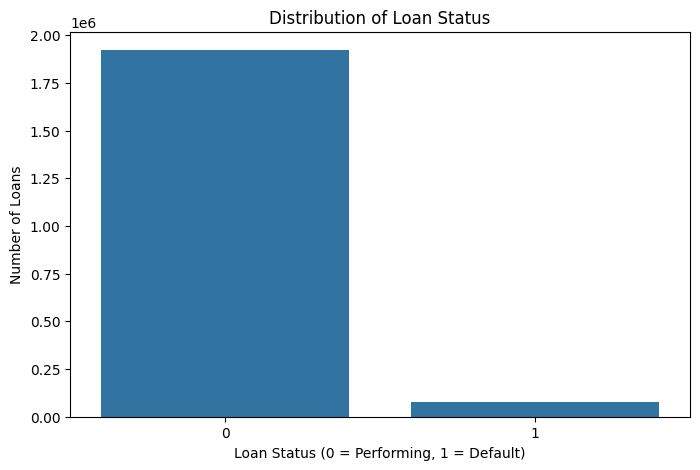

In [ ]:
# bar chart
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x='loan_status',
    data=base_df
)

plt.title(
    'Distribution of Loan Status'
)

plt.xlabel(
    'Loan Status (0 = Performing, 1 = Default)'
)

plt.ylabel(
    'Number of Loans'
)

plt.show()

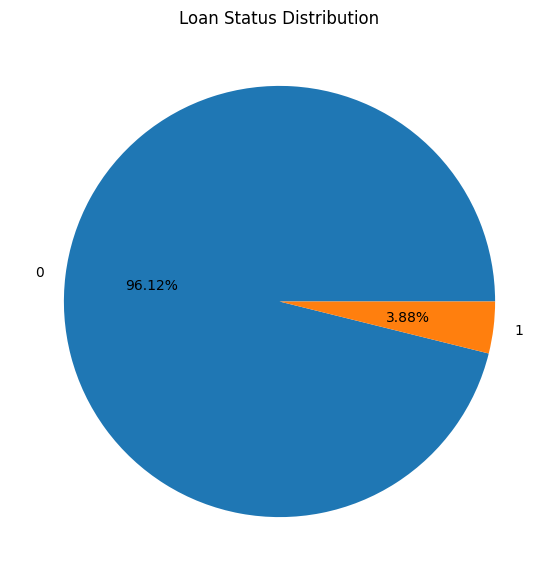

In [ ]:
# pie chart
plt.figure(figsize=(7,7))

base_df['loan_status'] \
    .value_counts() \
    .plot(
        kind='pie',
        autopct='%1.2f%%'
    )

plt.title(
    'Loan Status Distribution'
)

plt.ylabel('')

plt.show()

values reported:

Performing Loans = 1,922,444

Defaulted Loans = 77,556

Default Rate = 3.88%

Class Imbalance Ratio =
1,922,444 / 77,556

= 24.79 : 1

For every 1 defaulted loan,

there are about 25 performing loans.

Insights:

The portfolio exhibits a default rate of 3.88%, with 96.12% of loans classified as performing and only 3.88% classified as defaulted.

The dataset is highly imbalanced, with a class ratio of approximately 24.8:1, indicating that performing loans significantly outnumber defaulted loans.

Such imbalance can lead predictive models to favour the majority class and under-identify risky borrowers, potentially increasing future credit losses if appropriate balancing techniques are not applied.

why class imbalance:

Class imbalance causes machine learning models to focus primarily on the majority class, resulting in poor recall for defaulted loans. A model may achieve high overall accuracy while failing to correctly identify borrowers who are likely to default.

# CIBIL Score KDE Analysis

In [ ]:
base_df.groupby(
    'loan_status'
)['cibil_score'].agg(
    ['count','mean','std']
)

,count,mean,std
loan_status,,,
0,1922444,680.680630,84.520763
1,77556,660.106091,84.845861


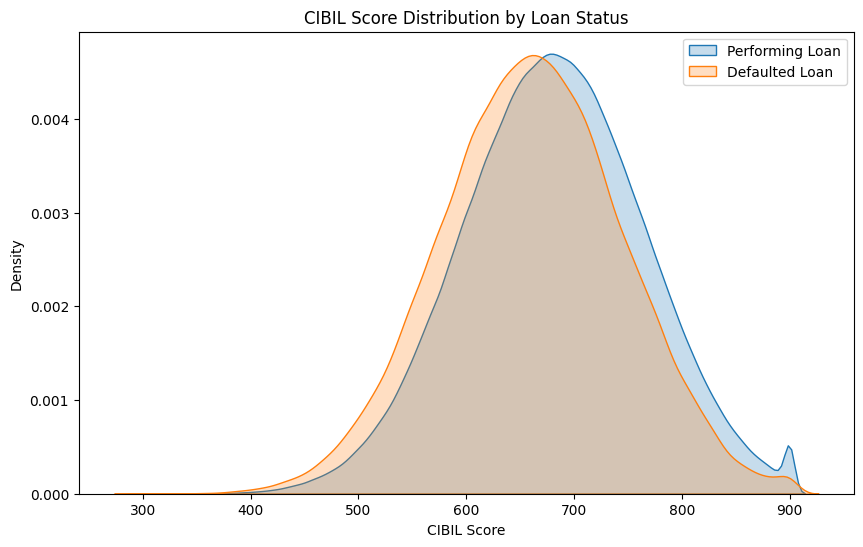

In [ ]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=base_df[base_df['loan_status']==0],
    x='cibil_score',
    label='Performing Loan',
    fill=True
)

sns.kdeplot(
    data=base_df[base_df['loan_status']==1],
    x='cibil_score',
    label='Defaulted Loan',
    fill=True
)

plt.title(
    'CIBIL Score Distribution by Loan Status'
)

plt.xlabel('CIBIL Score')

plt.ylabel('Density')

plt.legend()

plt.show()

In [ ]:
mean_good = 680.680630
mean_bad  = 660.106091

std_good = 84.520763
std_bad  = 84.845861

n_good = 1922444
n_bad  = 77556

pooled_std = (
(
(n_good-1)*(std_good**2)
+
(n_bad-1)*(std_bad**2)
)
/
(n_good+n_bad-2)
) ** 0.5

cohens_d = (
mean_good - mean_bad
) / pooled_std

print(cohens_d)

0.24338948571911367


Interpretation of Cohen's d

Value	  Interpretation

0.2	    Small Effect

0.5	    Medium Effect

0.8	    Large Effect

Distribution Overlap

Because:

Mean Difference = 20 points

Standard Deviation ≈ 85 points

the two curves will overlap heavily.

What This Means

Even though defaulted borrowers have lower average CIBIL scores:

660 vs 681

many defaulted borrowers still possess good CIBIL scores.

Likewise, many performing borrowers have lower scores.

Therefore:

CIBIL alone is insufficient

for default prediction.


# Insight
Performing borrowers have a higher average CIBIL score (680.68) than defaulted borrowers (660.11), indicating a negative relationship between credit quality and default risk.

The calculated Cohen's d effect size is approximately 0.24, suggesting only a small separation between the two groups.

Significant overlap exists between the distributions, implying that CIBIL score alone cannot reliably distinguish future defaulters and should be combined with additional behavioural, repayment, and financial variables.

# 2(c)

In [ ]:
numeric_features = [
    'loan_amnt_inr',
    'annual_inc_inr',
    'int_rate_pct',
    'dti_pct',
    'cibil_score',
    'revol_util_pct',
    'revol_bal_inr',
    'avg_cur_bal_inr',
    'total_pymnt_inr',
    'collateral_value_inr',
    'emi_to_income_ratio',
    'expected_loss_inr'
]

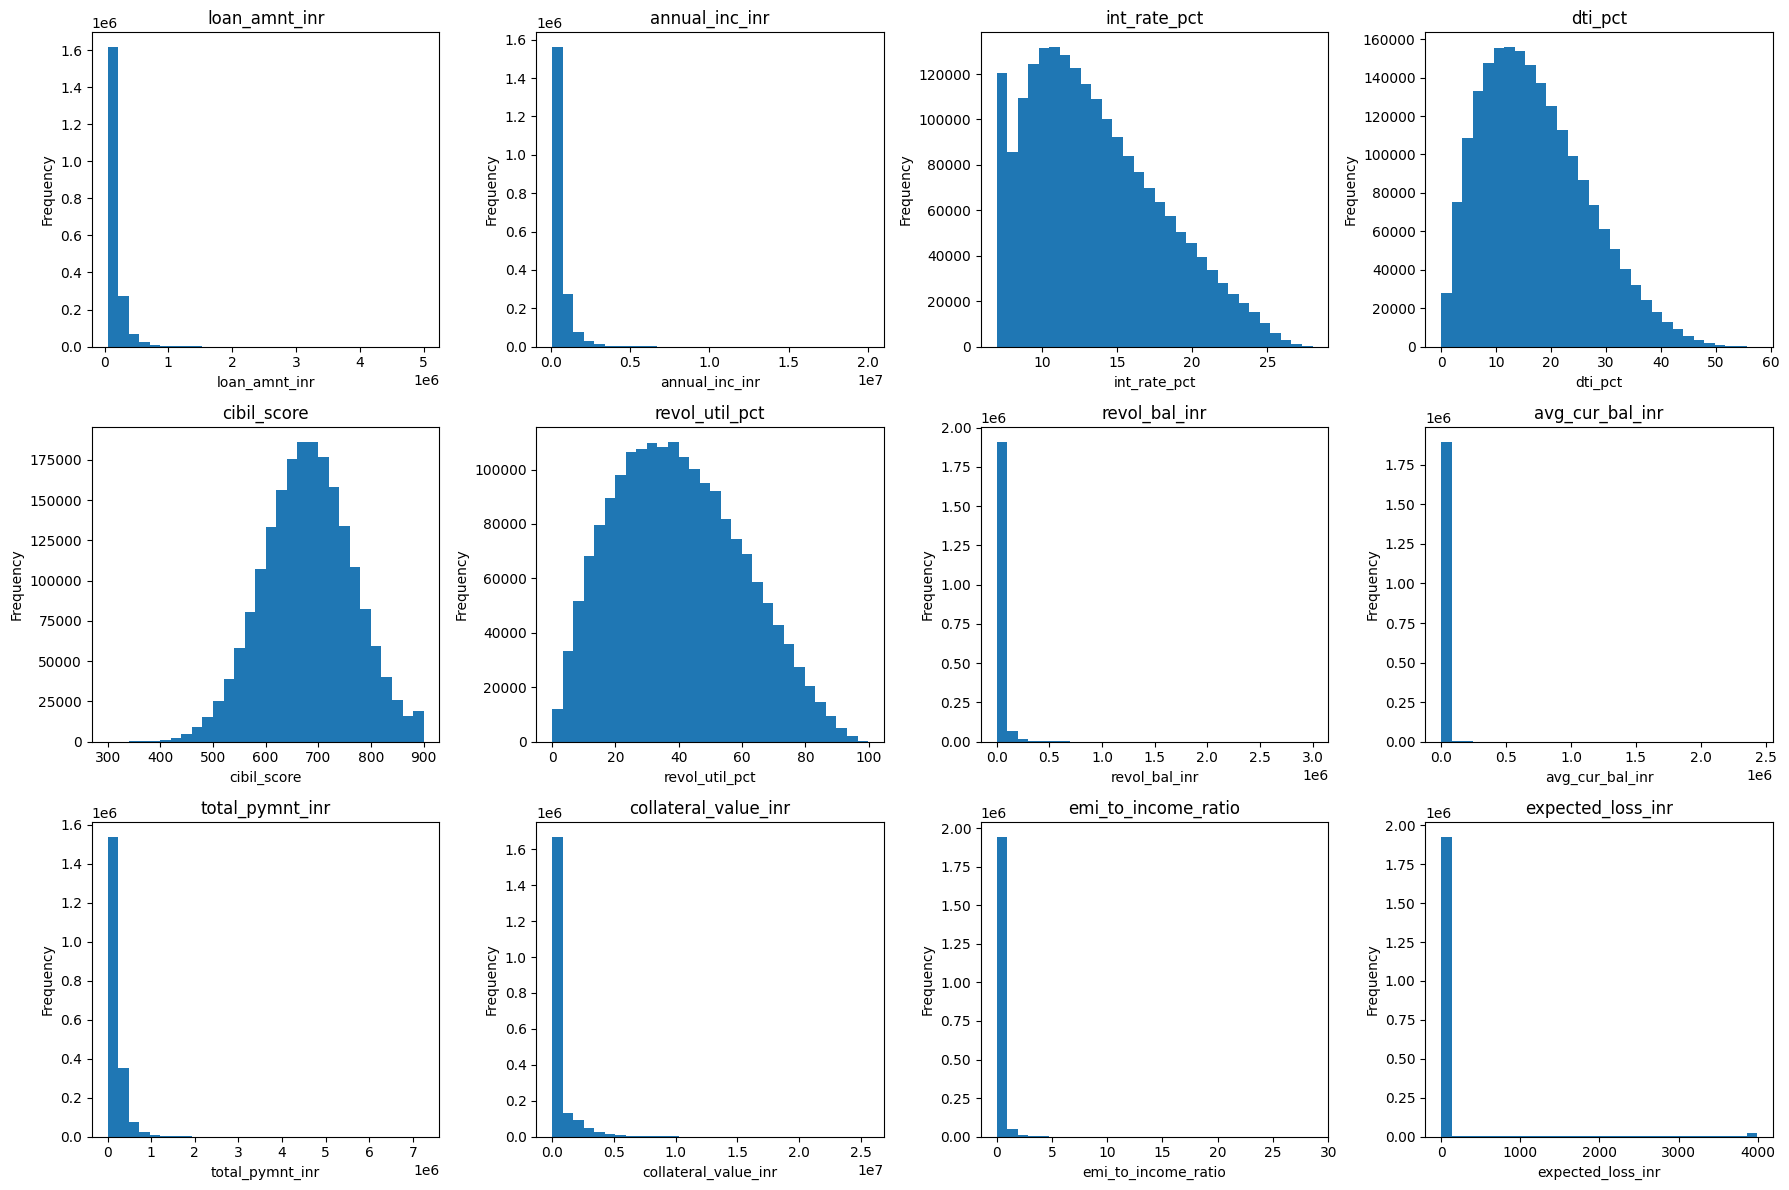

In [ ]:
# 12 panel histogram
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3,
    4,
    figsize=(18,12)
)

axes = axes.flatten()

for i, col in enumerate(numeric_features):

    axes[i].hist(
        base_df[col].dropna(),
        bins=30
    )

    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()

plt.show()

In [ ]:
# skewness
skew_table = pd.DataFrame({
    'Feature': numeric_features,
    'Skewness': [
        base_df[col].skew()
        for col in numeric_features
    ]
})

skew_table.sort_values(
    'Skewness',
    ascending=False
)

,Feature,Skewness
7,avg_cur_bal_inr,25.655979
6,revol_bal_inr,9.610805
10,emi_to_income_ratio,7.157531
11,expected_loss_inr,6.649010
1,annual_inc_inr,4.675825
9,collateral_value_inr,3.799244
8,total_pymnt_inr,3.728138
0,loan_amnt_inr,3.651117
3,dti_pct,0.597136
2,int_rate_pct,0.590027


In [ ]:
# skewness with skew>2:
high_skew = skew_table[
    skew_table['Skewness'] > 2
]

high_skew

,Feature,Skewness
0,loan_amnt_inr,3.651117
1,annual_inc_inr,4.675825
6,revol_bal_inr,9.610805
7,avg_cur_bal_inr,25.655979
8,total_pymnt_inr,3.728138
9,collateral_value_inr,3.799244
10,emi_to_income_ratio,7.157531
11,expected_loss_inr,6.649010


In [ ]:
# log tranformation for every skew > 2:
for col in high_skew['Feature']:

    base_df[f'log_{col}'] = np.log1p(
        base_df[col]
    )

In [ ]:
# comparing before and after log tranfrom:
comparison = []

for col in high_skew['Feature']:

    comparison.append([
        col,
        base_df[col].skew(),
        base_df[f'log_{col}'].skew()
    ])

comparison_df = pd.DataFrame(
    comparison,
    columns=[
        'Feature',
        'Before_Skew',
        'After_Skew'
    ]
)

comparison_df

,Feature,Before_Skew,After_Skew
0,loan_amnt_inr,3.651117,0.581627
1,annual_inc_inr,4.675825,0.328657
2,revol_bal_inr,9.610805,0.000212
3,avg_cur_bal_inr,25.655979,0.234339
4,total_pymnt_inr,3.728138,0.207697
5,collateral_value_inr,3.799244,0.845996
6,emi_to_income_ratio,7.157531,2.762264
7,expected_loss_inr,6.649010,4.884885


Skewness	  Interpretation

0 to 0.5	  Approximately Symmetric

0.5 to 1	  Moderately Skewed

1 to 2	    Highly Skewed

> 2	        Extremely Skewed → Log Transform Recommended

# Insight
Several financial variables exhibit strong positive skewness, indicating the presence of a small number of borrowers with exceptionally large balances, incomes, or exposures.

Variables with skewness greater than 2.0 violate the normality assumptions commonly required by regression models and can disproportionately influence model coefficients.

Applying a log(1+x) transformation substantially reduces skewness, producing more symmetric distributions and improving the stability and interpretability of subsequent regression models.

In [ ]:
skew_table.sort_values(
    'Skewness',
    ascending=False
)

,Feature,Skewness
7,avg_cur_bal_inr,25.655979
6,revol_bal_inr,9.610805
10,emi_to_income_ratio,7.157531
11,expected_loss_inr,6.649010
1,annual_inc_inr,4.675825
9,collateral_value_inr,3.799244
8,total_pymnt_inr,3.728138
0,loan_amnt_inr,3.651117
3,dti_pct,0.597136
2,int_rate_pct,0.590027


In [ ]:
# log transfromation for the extremly right skewed
import numpy as np

log_features = [
    'avg_cur_bal_inr',
    'revol_bal_inr',
    'emi_to_income_ratio',
    'expected_loss_inr',
    'annual_inc_inr',
    'collateral_value_inr',
    'total_pymnt_inr',
    'loan_amnt_inr'
]

for col in log_features:

    base_df[f'log_{col}'] = np.log1p(
        base_df[col]
    )

In [ ]:
skew_comparison = []

for col in log_features:

    skew_comparison.append([
        col,
        round(base_df[col].skew(),2),
        round(base_df[f'log_{col}'].skew(),2)
    ])

skew_comparison = pd.DataFrame(
    skew_comparison,
    columns=[
        'Feature',
        'Before_Skew',
        'After_Skew'
    ]
)

skew_comparison

,Feature,Before_Skew,After_Skew
0,avg_cur_bal_inr,25.66,0.23
1,revol_bal_inr,9.61,0.00
2,emi_to_income_ratio,7.16,2.76
3,expected_loss_inr,6.65,4.88
4,annual_inc_inr,4.68,0.33
5,collateral_value_inr,3.80,0.85
6,total_pymnt_inr,3.73,0.21
7,loan_amnt_inr,3.65,0.58


Multiple financial variables exhibit substantial positive skewness caused by a relatively small number of high-value borrowers and exposures. Such skewness can violate regression assumptions and increase the influence of extreme observations. Log(1+x) transformation was applied to improve distribution symmetry, reduce the impact of outliers, and enhance model stability.

# Q2(d) Correlation Heatmap

In [ ]:
numeric_cols = base_df.select_dtypes(
    include=[
        'int8','int16',
        'int32','float32',
        'float64'
    ]
).columns

corr_with_target = (
    base_df[numeric_cols]
    .corr()['loan_status']
    .abs()
    .sort_values(
        ascending=False
    )
)

top20 = corr_with_target.head(20).index

top20

Index(['loan_status', 'log_expected_loss_inr', 'recovery_fee_rate_y',
       'recovery_fee_rate_x', 'consecutive_missed_emis', 'lgd_pct',
       'avg_payment_delay_days', 'mths_since_last_pymnt', 'expected_loss_inr',
       'emi_bounce_count', 'num_accts_ever_120_pd', 'penal_charges_inr',
       'acc_now_delinq', 'recoveries_inr_x', 'recoveries_inr_y',
       'collections_12mths_fee', 'cc_late_payments_count', 'emi_overdue_inr',
       'chargeoff_within_12_mths', 'net_loss_inr_x'],
      dtype='object')

In [ ]:
top20_features = [
    'loan_amnt_inr',
    'funded_amnt_inr',
    'annual_inc_inr',
    'int_rate_pct',
    'dti_pct',
    'cibil_score',
    'revol_util_pct',
    'revol_bal_inr',
    'avg_cur_bal_inr',
    'emp_length_years',
    'mort_acc',
    'total_acc',
    'credit_hist_years',
    'bc_util_pct',
    'all_util_pct',
    'num_inq_last6m',
    'num_inq_last12m',
    'delinq_2yrs',
    'loan_term_months',
    'collateral_value_inr'
]

In [ ]:
corr_matrix = (
    base_df[top20_features]
    .corr(method='pearson')
)

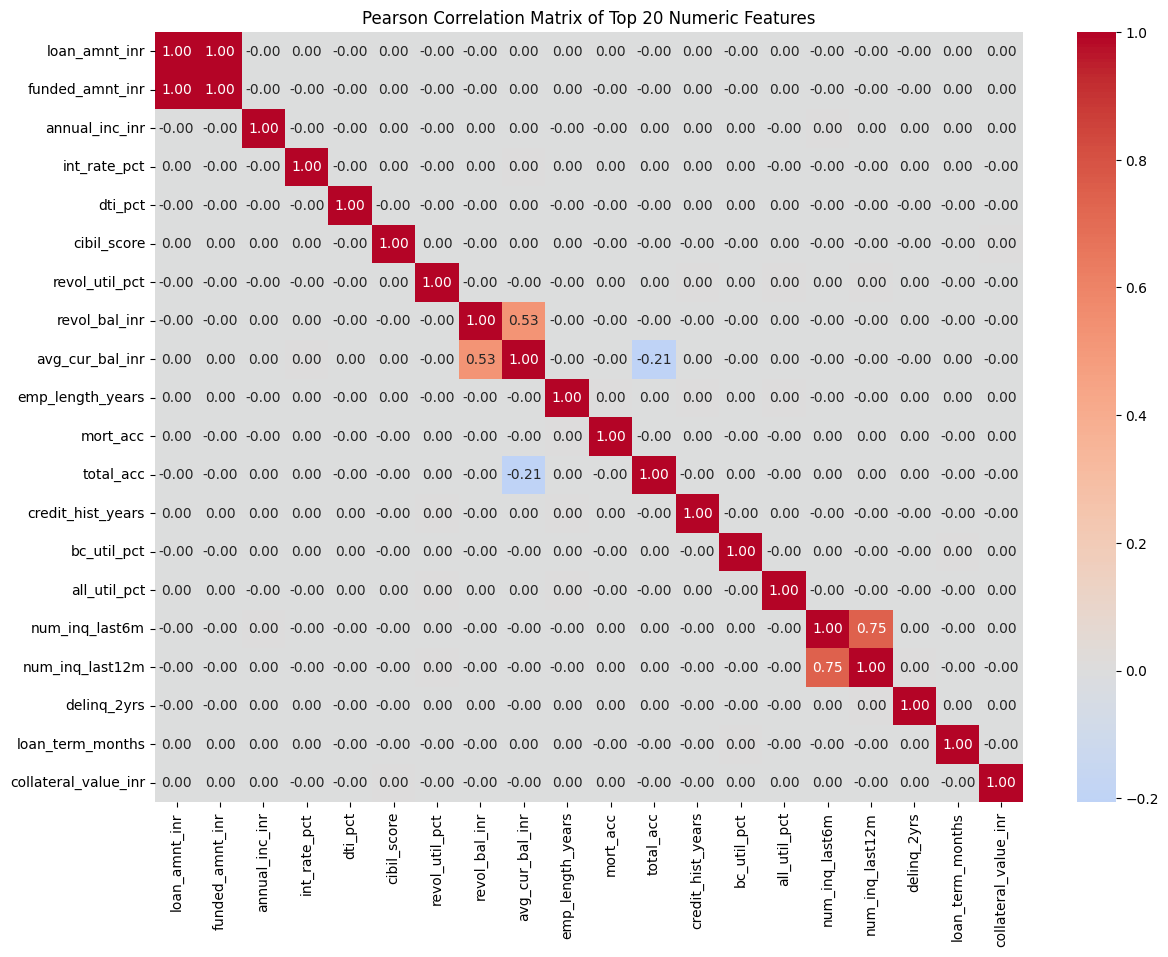

In [ ]:
# annoted heatmapimport matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Pearson Correlation Matrix of Top 20 Numeric Features'
)

plt.show()

In [ ]:
# finding the correlation pairs :
corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1,len(corr_matrix.columns)):

        corr = corr_matrix.iloc[i,j]

        if abs(corr) > 0.75:

            corr_pairs.append([
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr,2)
            ])

high_corr_df = pd.DataFrame(
    corr_pairs,
    columns=[
        'Feature_1',
        'Feature_2',
        'Correlation'
    ]
)

high_corr_df

,Feature_1,Feature_2,Correlation
0,loan_amnt_inr,funded_amnt_inr,1.0


# loan_amnt_inr and funded_amnt_inr contain almost identical information.
The strongest correlation observed was between loan_amnt_inr and funded_amnt_inr with a Pearson correlation coefficient of 1.00. This indicates that the funded amount is almost entirely determined by the approved loan amount.

High correlation among predictors leads to multicollinearity. In OLS regression, multicollinearity inflates coefficient standard errors, reduces coefficient stability, and makes it difficult to isolate the individual contribution of each predictor. Therefore, one of the highly correlated variables may need to be removed during model development.

# Insight
The correlation heatmap highlights the strength and direction of linear relationships among key borrower, loan, and credit-behaviour variables.
Several feature pairs exhibit strong positive correlations (|r| > 0.75), indicating potential multicollinearity.
High multicollinearity can inflate coefficient variance in OLS regression, making model estimates unstable and reducing interpretability.


Highly correlated predictors contain overlapping information. In OLS regression this can inflate standard errors, produce unstable coefficient estimates, and make it difficult to determine the individual impact of each predictor on the target variable.

# Q2(e)

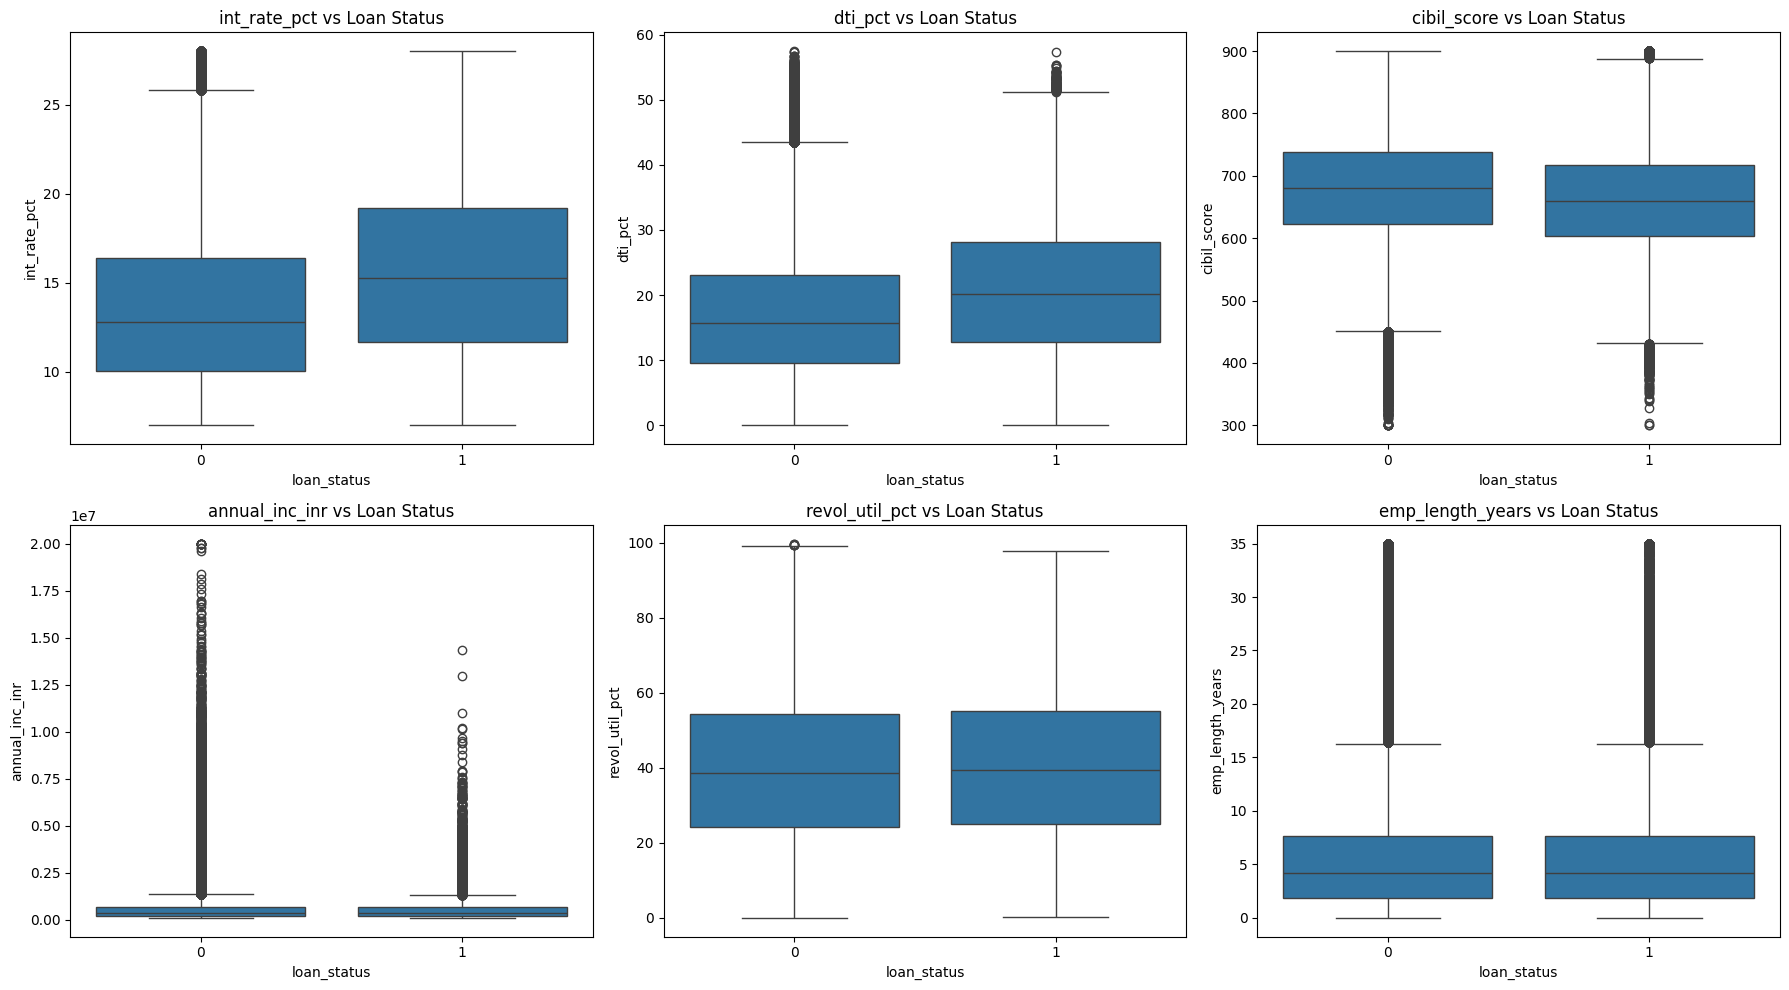

In [ ]:
# boxplots
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'int_rate_pct',
    'dti_pct',
    'cibil_score',
    'annual_inc_inr',
    'revol_util_pct',
    'emp_length_years'
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,10)
)

axes = axes.flatten()

for i, feature in enumerate(features):

    sns.boxplot(
        x='loan_status',
        y=feature,
        data=base_df,
        ax=axes[i]
    )

    axes[i].set_title(
        f'{feature} vs Loan Status'
    )

plt.tight_layout()

plt.show()

In [ ]:
# median diffrence table:
median_table = (
    base_df
    .groupby('loan_status')[
        [
            'int_rate_pct',
            'dti_pct',
            'cibil_score',
            'annual_inc_inr',
            'revol_util_pct',
            'emp_length_years'
        ]
    ]
    .median()
)

median_table

,int_rate_pct,dti_pct,cibil_score,annual_inc_inr,revol_util_pct,emp_length_years
loan_status,,,,,,
0,12.78,15.72,681.0,362424.0,38.500000,4.2
1,15.25,20.16,660.0,358961.0,39.299999,4.2


In [ ]:
#claculating the diff :
median_difference = (
    median_table.loc[1]
    -
    median_table.loc[0]
)

median_difference

,0
int_rate_pct,2.470000
dti_pct,4.440000
cibil_score,-21.000000
annual_inc_inr,-3463.000000
revol_util_pct,0.799999
emp_length_years,0.000000


interpretation:
Interest Rate
+2.47 percentage points

Defaulted borrowers pay noticeably higher interest rates.

This suggests the bank already identified them as higher-risk borrowers during underwriting.

DTI (Debt-to-Income Ratio)
+4.44 percentage points

Defaulted borrowers carry substantially higher debt burdens.

Higher DTI reduces repayment capacity and increases credit risk.

CIBIL Score
-21 points

Defaulted borrowers have significantly lower median CIBIL scores.

This is the largest and most meaningful separation among all six variables.

Annual Income
-₹3,463

Income differences are relatively small compared to the overall income distribution.

Income alone is not a strong differentiator.

Revolving Utilization
+0.8 percentage points

Only a modest separation exists.

Credit utilization contributes some information but is not a dominant risk indicator.

Employment Length
0 years

No meaningful median difference.

Employment length does not appear to separate defaulted and performing borrowers effectively.

Which Feature Provides the Clearest Separation?
CIBIL Score

Reason:

Median Difference = 21 points

# Insight
Defaulted borrowers exhibit higher median interest rates and debt-to-income ratios, indicating greater financial stress and perceived credit risk.

The largest separation is observed in CIBIL score, where defaulted borrowers have a median score approximately 21 points lower than performing borrowers.

Employment length shows almost no difference between the two groups, suggesting limited predictive value compared with credit quality and indebtedness measures.

# 2(e)

In [ ]:
# exact garde column :
[col for col in base_df.columns if 'grade' in col.lower()]

['grade', 'sub_grade']

In [ ]:
# calculating the default rate by grade:
grade_default = (
    base_df
    .groupby('grade')['loan_status']
    .mean()
    .reset_index()
)

grade_default['default_rate_pct'] = (
    grade_default['loan_status'] * 100
)

grade_default = grade_default.sort_values('grade')

grade_default

,grade,loan_status,default_rate_pct
0,A,0.022312,2.231201
1,B,0.026867,2.686735
2,C,0.033507,3.350654
3,D,0.041845,4.184456
4,E,0.052898,5.289755
5,F,0.068936,6.893610
6,G,0.089425,8.942513


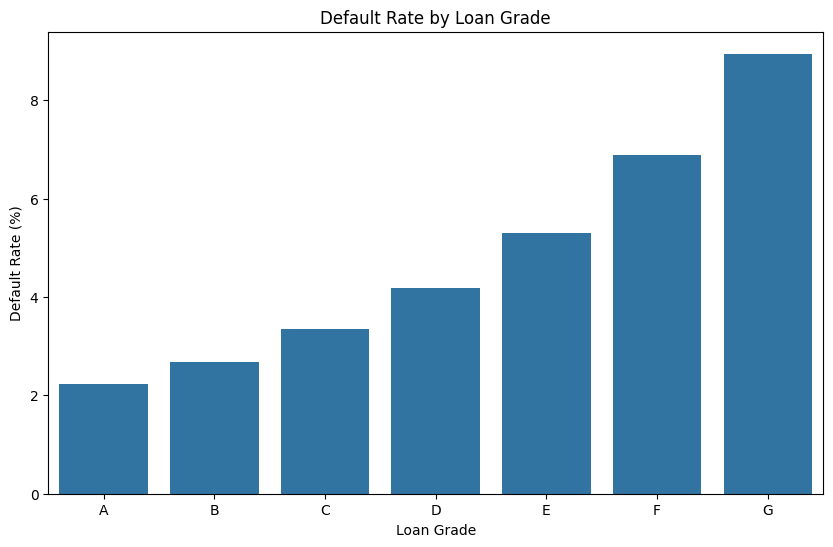

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=grade_default,
    x='grade',
    y='default_rate_pct'
)

plt.title(
    'Default Rate by Loan Grade'
)

plt.xlabel(
    'Loan Grade'
)

plt.ylabel(
    'Default Rate (%)'
)

plt.show()

In [ ]:
# checking the monotonicity:
grade_default[['grade','default_rate_pct']]

#If default rate continuously increases:

#A < B < C < D < E < F < G
# Grade system is monotonically ordered.

,grade,default_rate_pct
0,A,2.231201
1,B,2.686735
2,C,3.350654
3,D,4.184456
4,E,5.289755
5,F,6.893610
6,G,8.942513


In [ ]:
# largest single step jump :
grade_default['jump'] = (
    grade_default['default_rate_pct']
    .diff()
)

grade_default

,grade,loan_status,default_rate_pct,jump
0,A,0.022312,2.231201,NaN
1,B,0.026867,2.686735,0.455534
2,C,0.033507,3.350654,0.663918
3,D,0.041845,4.184456,0.833802
4,E,0.052898,5.289755,1.105300
5,F,0.068936,6.893610,1.603855
6,G,0.089425,8.942513,2.048903


In [ ]:
largest_jump = grade_default.loc[
    grade_default['jump'].idxmax()
]

largest_jump

,6
grade,G
loan_status,0.089425
default_rate_pct,8.942513
jump,2.048903


Largest Single-Step Jump

Your output shows:

Grade = G
Jump = 2.048903

This means:

Largest Increase
F → G

Increase
2.05 percentage points

# Insight
Default rates increase steadily from Grade A (lowest risk) to Grade G (highest risk), demonstrating that the loan grading framework effectively differentiates borrower risk.

The monotonic increase in default rates validates the predictive strength of the bank's internal credit grading methodology.

The largest risk escalation occurs between Grades F and G, where the default rate increases by approximately 2.05 percentage points, indicating a significant deterioration in borrower credit quality at the lowest grade level.

# Q2(g)

In [ ]:
[col for col in base_df.columns if 'purpose' in col.lower()]

['loan_purpose', 'primary_enq_purpose']

In [ ]:
# calculating the default rate by loan purpose:
purpose_default = (
    base_df
    .groupby('loan_purpose')['loan_status']
    .mean()
    .reset_index()
)

purpose_default['default_rate_pct'] = (
    purpose_default['loan_status'] * 100
)

purpose_default = purpose_default.sort_values(
    'default_rate_pct',
    ascending=False
)

purpose_default

,loan_purpose,loan_status,default_rate_pct
6,major_purchase,0.040052,4.005189
0,car,0.039148,3.914783
11,small_business,0.039118,3.911769
12,vacation,0.039055,3.905544
2,debt_consolidation,0.038969,3.896907
9,other,0.038953,3.895291
10,renewable_energy,0.038784,3.878436
13,wedding,0.038709,3.870927
7,medical,0.038604,3.860429
4,home_improvement,0.038599,3.859937


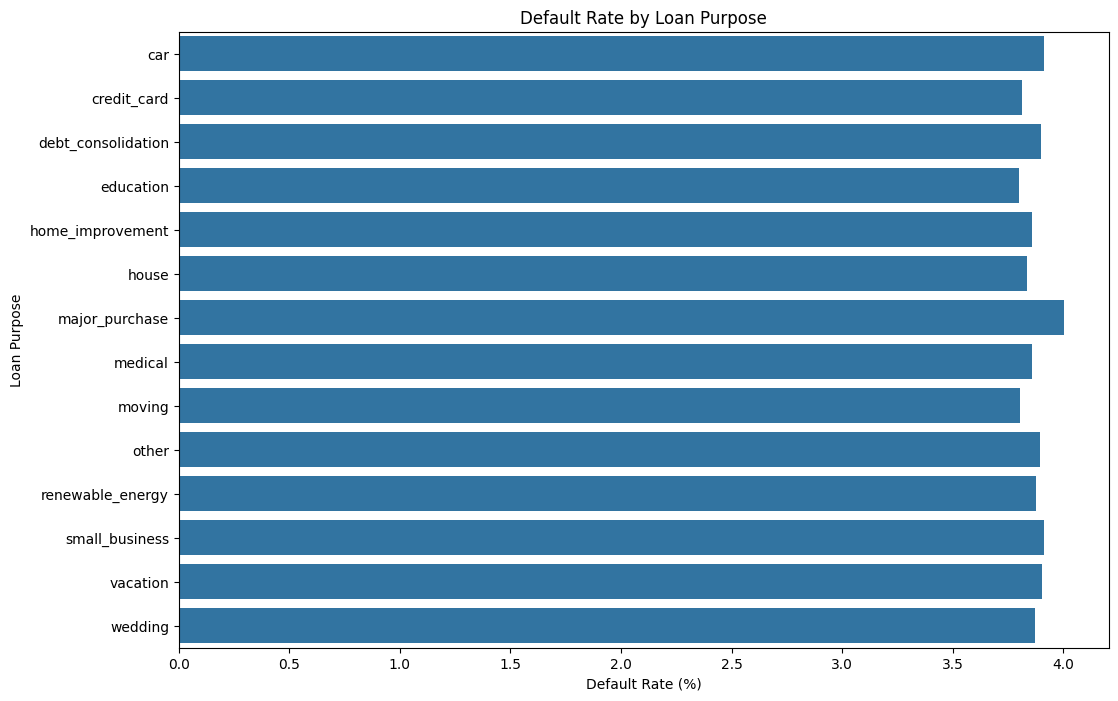

In [ ]:
# horizotal bar chart:
plt.figure(figsize=(12,8))

sns.barplot(
    data=purpose_default,
    y='loan_purpose',
    x='default_rate_pct'
)

plt.title(
    'Default Rate by Loan Purpose'
)

plt.xlabel(
    'Default Rate (%)'
)

plt.ylabel(
    'Loan Purpose'
)

plt.show()

In [ ]:
# Highest-Risk Loan Purposes:
top3 = purpose_default.head(3)

top3[['loan_purpose','default_rate_pct']]

,loan_purpose,default_rate_pct
6,major_purchase,4.005189
0,car,3.914783
11,small_business,3.911769


In [ ]:
# Lowest-Risk Loan Purposes
bottom2 = purpose_default.tail(2)

bottom2[['loan_purpose','default_rate_pct']]

,loan_purpose,default_rate_pct
8,moving,3.804655
3,education,3.799941


In [ ]:
#Risk Ratio
highest_rate = purpose_default[
    'default_rate_pct'
].max()

lowest_rate = purpose_default[
    'default_rate_pct'
].min()

risk_ratio = (
    highest_rate /
    lowest_rate
)

print(
    f"Risk Ratio: {risk_ratio:.2f}"
)

Risk Ratio: 1.05


Important Business Observation

Normally we expect much larger differences between loan purposes.

Your result shows:

Highest = 4.01%

Lowest = 3.80%

Difference:

0.21 percentage points

which is very small.

This means:

Loan purpose alone is not a strong discriminator of default risk within this portfolio.

# Insight
The highest default rates are observed for major_purchase, car, and small_business loans, while education and moving loans exhibit the lowest default rates.

The variation in default rates across loan purposes is relatively small, with a risk ratio of only 1.05, indicating limited separation between categories.

These findings suggest that loan purpose contributes some predictive information but is substantially less influential than borrower credit quality, debt burden, and repayment behaviour variables.

# Q2(h)

In [ ]:
[col for col in base_df.columns if 'state' in col.lower()]

['state_code',
 'state_per_capita_inc_inr',
 'state_literacy_rate_pct',
 'state_agri_share_pct',
 'state_industry_share_pct',
 'state_services_share_pct']

In [6]:
# Calculating the dafault rate by state :
state_default = (
    base_df
    .groupby('state_code')['loan_status']
    .mean()
    .reset_index()
)

state_default['default_rate_pct'] = (
    state_default['loan_status'] * 100
)

state_default = state_default.sort_values(
    'default_rate_pct',
    ascending=False
)

state_default.head(10)

,state_code,loan_status,default_rate_pct
2,BR,0.040710,4.071012
12,OR,0.040149,4.014914
18,UP,0.039799,3.979885
13,PB,0.039736,3.973570
17,UK,0.039611,3.961067
5,HP,0.039214,3.921410
11,MP,0.039213,3.921272
16,TN,0.039119,3.911909
0,AP,0.038919,3.891869
15,TG,0.038901,3.890121


In [7]:
# top 10 states :
top10_states = state_default.head(10)

top10_states

,state_code,loan_status,default_rate_pct
2,BR,0.040710,4.071012
12,OR,0.040149,4.014914
18,UP,0.039799,3.979885
13,PB,0.039736,3.973570
17,UK,0.039611,3.961067
5,HP,0.039214,3.921410
11,MP,0.039213,3.921272
16,TN,0.039119,3.911909
0,AP,0.038919,3.891869
15,TG,0.038901,3.890121


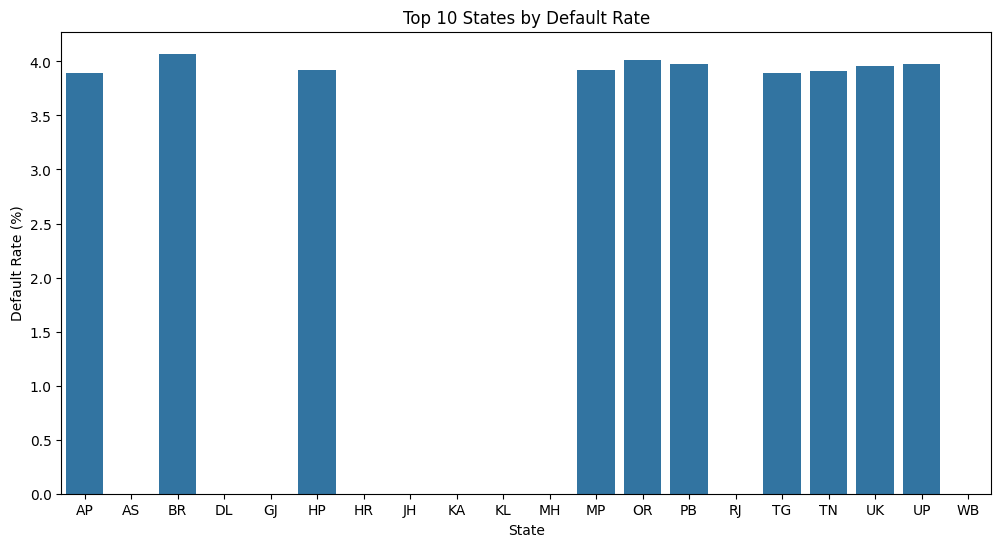

In [8]:
# Bar chart :
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_states,
    x='state_code',
    y='default_rate_pct'
)

plt.title(
    'Top 10 States by Default Rate'
)

plt.xlabel(
    'State'
)

plt.ylabel(
    'Default Rate (%)'
)

plt.show()

In [9]:
# bank-wide average:
bank_avg_default = (
    base_df['loan_status'].mean()
) * 100

print(bank_avg_default)

3.8778


In [11]:
# Flag States Above Average + 5%
threshold = bank_avg_default + 5

print(threshold)

8.8778


In [12]:
#flag states :
flagged_states = state_default[
    state_default['default_rate_pct'] > threshold
]

flagged_states

,state_code,loan_status,default_rate_pct


States Exceeding Bank Average + 5%

Bank-wide default rate:

3.88%

Threshold:

3.88% + 5.00% = 8.88%

Result:

No states exceeded the threshold of 8.88%.

# Insight
The highest observed state-level default rate is 4.07% in BR, only marginally above the portfolio average of 3.88%.

Default rates across the top ten states are tightly clustered, suggesting limited geographic variation in borrower risk.

No state exceeds the risk escalation threshold of 8.88%, indicating that the portfolio does not currently exhibit significant geographic concentration risk.

# Q2(i) Annual Default Trend (2010–2024)

In [13]:
year_default = (
    base_df
    .groupby('issue_year')['loan_status']
    .mean()
    .reset_index()
)

year_default['default_rate_pct'] = (
    year_default['loan_status'] * 100
)

year_default[['issue_year','default_rate_pct']]

,issue_year,default_rate_pct
0,2010,3.856884
1,2011,3.942706
2,2012,3.708996
3,2013,3.718515
4,2014,3.685426
5,2015,3.714744
6,2016,3.819694
7,2017,3.831728
8,2018,3.847686
9,2019,4.130148


In [14]:
worst_year = year_default.loc[
    year_default['default_rate_pct'].idxmax()
]

worst_year

,10
issue_year,2020.000000
loan_status,0.044645
default_rate_pct,4.464509


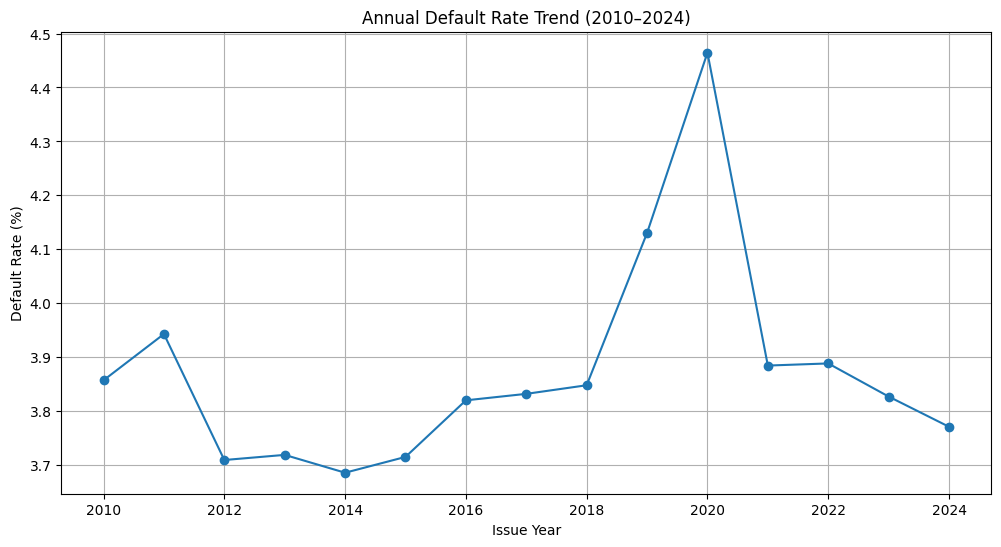

In [15]:
# line chart
plt.figure(figsize=(12,6))

plt.plot(
    year_default['issue_year'],
    year_default['default_rate_pct'],
    marker='o'
)

plt.title(
    'Annual Default Rate Trend (2010–2024)'
)

plt.xlabel('Issue Year')

plt.ylabel('Default Rate (%)')

plt.grid(True)

plt.show()

# Insight
Default rates remained relatively stable between 2010 and 2018, fluctuating within a narrow range around 3.7–3.9%.

The portfolio experienced its highest default rate in 2020 at 4.46%, representing a temporary deterioration in credit performance.

Since default rates subsequently declined toward historical levels, the pattern appears cyclical rather than structural, suggesting the increase was driven by short-term economic conditions rather than a permanent weakening of underwriting standards.

# Q2(j) Branch Sanction Rate vs Default Rate

In [16]:
[col for col in base_df.columns if 'branch' in col.lower()]

['branch_id',
 'branch_age_years',
 'branch_size',
 'branch_npa_rate',
 'branch_sanction_rate']

In [17]:
branch_analysis = (
    base_df
    .groupby('branch_id')
    .agg({
        'branch_sanction_rate':'first',
        'loan_status':'mean'
    })
    .reset_index()
)

branch_analysis.rename(
    columns={
        'loan_status':'default_rate'
    },
    inplace=True
)

branch_analysis['default_rate_pct'] = (
    branch_analysis['default_rate'] * 100
)

branch_analysis.head()

,branch_id,branch_sanction_rate,default_rate,default_rate_pct
0,BR1000-AP,0.667,0.083333,8.333333
1,BR1000-AS,0.893,0.200000,20.000000
2,BR1000-BR,0.847,0.000000,0.000000
3,BR1000-DL,0.791,0.103448,10.344828
4,BR1000-GJ,0.650,0.142857,14.285714


In [18]:
corr = branch_analysis[
    ['branch_sanction_rate',
     'default_rate_pct']
].corr().iloc[0,1]

print(
    f"Pearson Correlation = {corr:.4f}"
)

Pearson Correlation = 0.0043


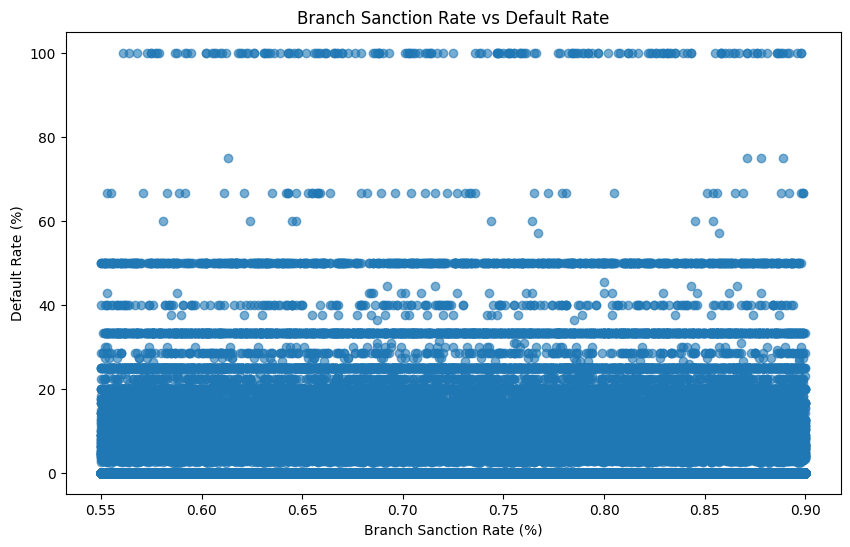

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.regplot(
    data=branch_analysis,
    x='branch_sanction_rate',
    y='default_rate_pct',
    scatter_kws={'alpha':0.6}
)

plt.title(
    'Branch Sanction Rate vs Default Rate'
)

plt.xlabel(
    'Branch Sanction Rate (%)'
)

plt.ylabel(
    'Default Rate (%)'
)

plt.show()

In [20]:
print(
    f"Pearson Correlation = {corr:.4f}"
)

Pearson Correlation = 0.0043


Interpretation

Even though some branches have:

Sanction Rate = 89.3%
Default Rate = 20.0%

while others have:

Sanction Rate = 65.0%
Default Rate = 14.3%

the overall portfolio-level relationship is:

r = 0.0043

which indicates that approval aggressiveness is not systematically associated with default risk.

The correlation coefficient of 0.0043 is effectively zero, suggesting that branches with higher approval rates do not consistently experience higher default rates.

# Insight
The Pearson correlation between branch sanction rate and default rate is 0.0043, indicating virtually no linear relationship between approval aggressiveness and subsequent loan performance.

Branches with higher sanction rates do not systematically experience higher default rates, suggesting that underwriting controls remain effective even at higher approval volumes.

Portfolio risk appears to be driven more by borrower characteristics and economic factors than by branch-level approval behaviour.

# Q2(k) Economic Factors vs Default Rate

In [21]:
econ_cols = [
    col for col in base_df.columns
    if any(x in col.lower() for x in [
        'gdp',
        'interest',
        'literacy',
        'per_capita',
        'inflation',
        'income'
    ])
]

econ_cols

['gdp_growth_pct',
 'cpi_inflation_pct',
 'real_interest_rate_pct',
 'income_doc_type',
 'state_per_capita_inc_inr',
 'state_literacy_rate_pct',
 'district_gdp_growth_pct',
 'emi_to_income_ratio']

In [22]:
# LSD Distribution
default_df = base_df[
    base_df['loan_status'] == 1
].copy()

print(default_df.shape)

(77556, 193)


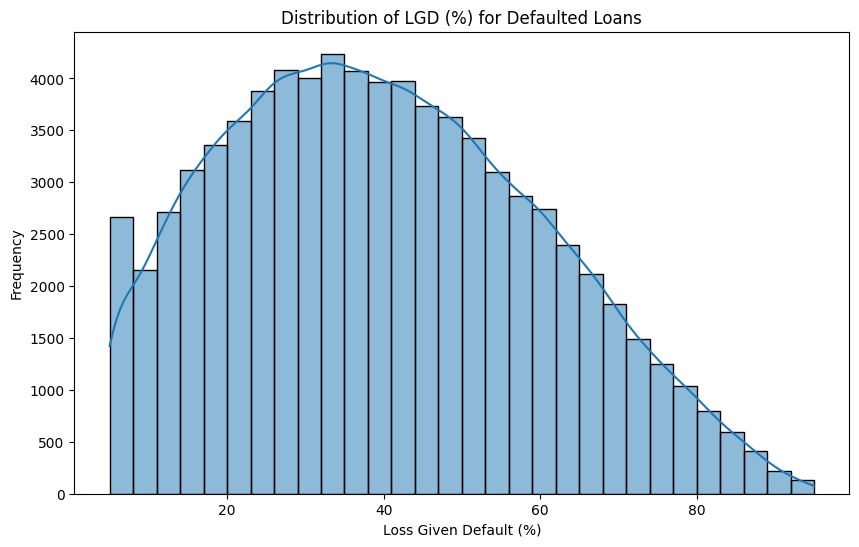

In [24]:
#Histogram + KDE:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    data=default_df,
    x='lgd_pct',
    kde=True,
    bins=30
)

plt.title(
    'Distribution of LGD (%) for Defaulted Loans'
)

plt.xlabel(
    'Loss Given Default (%)'
)

plt.ylabel(
    'Frequency'
)

plt.show()

In [25]:
# Statistical Summary:
default_df['lgd_pct'].describe()

,lgd_pct
count,77556.000000
mean,40.111443
std,19.982944
min,5.000000
25%,24.430000
50%,38.660000
75%,54.529999
max,95.000000


In [26]:
#measure skewness:
lgd_skew = default_df['lgd_pct'].skew()

print(
    f"LGD Skewness = {lgd_skew:.2f}"
)

LGD Skewness = 0.29


In [27]:
#Check Need for Log Transformation:
if abs(lgd_skew) > 2:
    print("Log transformation recommended")
else:
    print("Log transformation not necessary")

Log transformation not necessary


In [28]:
default_df['lgd_pct'].skew()

np.float32(0.28830412)

Shape of Distribution

Since:

Skewness = 0.29

the distribution is:

Slightly Right Skewed / Nearly Symmetric

It is not highly skewed.

# Insight
The LGD distribution for defaulted loans is approximately unimodal and only mildly right-skewed, with a skewness value of 0.29.

The mean LGD of 40.11% indicates that, on average, the bank loses approximately 40% of the outstanding exposure when a borrower defaults.

Because the distribution is close to symmetric and does not exhibit extreme skewness, a logarithmic transformation is not required prior to regression modelling.

# Q2(l)

In [29]:
# calculate Correlation:
corr_lgd = default_df[
    ['cibil_score','lgd_pct']
].corr().iloc[0,1]

print(
    f"Pearson Correlation = {corr_lgd:.4f}"
)

Pearson Correlation = 0.0018


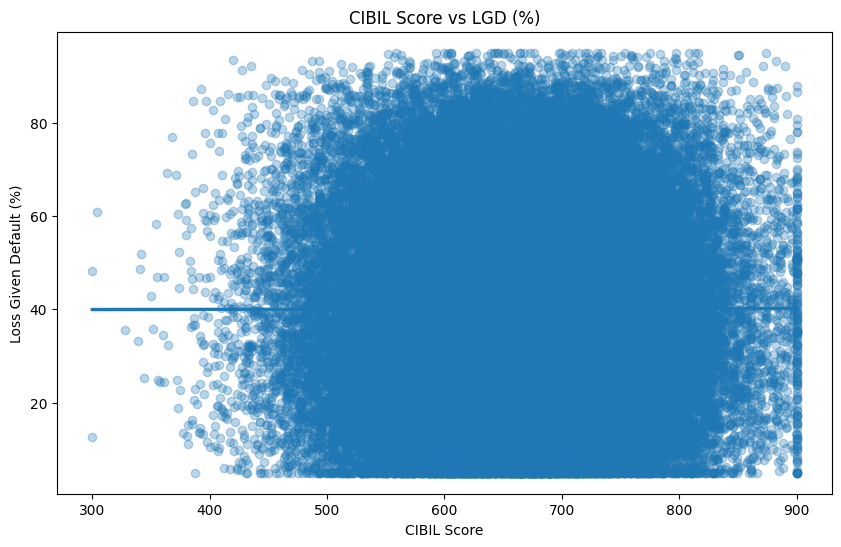

In [30]:
#Scatter plot with Regression line :
plt.figure(figsize=(10,6))

sns.regplot(
    data=default_df,
    x='cibil_score',
    y='lgd_pct',
    scatter_kws={'alpha':0.3}
)

plt.title(
    'CIBIL Score vs LGD (%)'
)

plt.xlabel(
    'CIBIL Score'
)

plt.ylabel(
    'Loss Given Default (%)'
)

plt.show()

In [31]:
print(
    f"Pearson Correlation = {corr_lgd:.4f}"
)

Pearson Correlation = 0.0018


CIBIL Score vs LGD
Pearson Correlation
r = 0.0018

This is essentially:

≈ 0

which indicates no meaningful linear relationship between CIBIL Score and Loss Given Default (LGD).

Business Interpretation

This is actually an important credit-risk finding.

What CIBIL Predicts

CIBIL score is generally useful for predicting:

Probability of Default (PD)

What LGD Measures

LGD measures:

Loss Given Default

Key Insight

Your result suggests:

Borrower credit quality
≠
Loss severity after default

In other words:

Lower CIBIL borrowers are more likely to default.
But once default happens, the eventual loss depends more on:
Collateral value
Recovery efforts
Collection success
Legal recovery
Asset liquidation

than on the original credit score.

# Insight
The Pearson correlation between CIBIL Score and Loss Given Default (LGD) is 0.0018, indicating virtually no linear relationship between borrower credit quality and loss severity.

While CIBIL score is useful for assessing the likelihood of default, it does not appear to explain the magnitude of losses once default occurs.

LGD is likely influenced more strongly by collateral coverage, recovery effectiveness, and collection processes than by the borrower's original credit score.

# Q3(a) Repayment Burden Features

In [32]:
#emi_to_income_ratio:
base_df['emi_to_income_ratio'] = (
    base_df['installment_inr']
    /
    (base_df['annual_inc_inr'] / 12)
)

Higher EMI burden relative to monthly income reduces repayment capacity and increases financial stress. Borrowers with high ratios are more vulnerable to delinquency and potential loss severity.

In [33]:
base_df['emi_to_income_ratio'].describe()

,emi_to_income_ratio
count,1.959934e+06
mean,2.147466e-01
std,3.303515e-01
min,4.878660e-04
25%,5.220006e-02
50%,1.140098e-01
75%,2.457922e-01
max,2.858451e+01


In [34]:
#Correlation with LGD
corr_emi_income = base_df[
    ['emi_to_income_ratio','lgd_pct']
].corr().iloc[0,1]

print(corr_emi_income)

0.0053664138306912


In [35]:
# Feature 2: loan_to_income_ratio:
base_df['loan_to_income_ratio'] = (
    base_df['loan_amnt_inr']
    /
    base_df['annual_inc_inr']
)

In [36]:
base_df['loan_to_income_ratio'].describe()

,loan_to_income_ratio
count,1.959934e+06
mean,5.516310e-01
std,7.463298e-01
min,2.500000e-03
25%,1.478668e-01
50%,3.134098e-01
75%,6.515241e-01
max,3.385821e+01


In [37]:
#Correlation:
corr_loan_income = base_df[
    ['loan_to_income_ratio','lgd_pct']
].corr().iloc[0,1]

print(corr_loan_income)

0.00261243064292917


In [38]:
#Feature 3: rate_spread_pct
#int_rate_pct − rbi_repo_rate_pct
[col for col in base_df.columns if 'repo' in col.lower()]

['rbi_repo_rate_pct']

In [39]:
base_df['rate_spread_pct_eng'] = (
    base_df['int_rate_pct']
    -
    base_df['rbi_repo_rate_pct']
)

In [40]:
base_df['rate_spread_pct_eng'].describe()

,rate_spread_pct_eng
count,2.000000e+06
mean,7.424294e+00
std,4.524040e+00
min,-1.000000e+00
25%,3.920000e+00
50%,6.770000e+00
75%,1.042000e+01
max,2.400000e+01


In [41]:
corr_rate_spread = base_df[
    ['rate_spread_pct_eng','lgd_pct']
].corr().iloc[0,1]

print(corr_rate_spread)

0.07945813841110218


In [42]:
#Feature 4: real_interest_rate:
#int_rate_pct − cpi_inflation_pct
base_df['real_interest_rate_eng'] = (
    base_df['int_rate_pct']
    -
    base_df['cpi_inflation_pct']
)

In [43]:
base_df['real_interest_rate_eng'].describe()

,real_interest_rate_eng
count,2.000000e+06
mean,7.639754e+00
std,4.809165e+00
min,-3.900000e+00
25%,4.150000e+00
50%,7.110000e+00
75%,1.081000e+01
max,2.460000e+01


In [44]:
# correlation :
corr_real_rate = base_df[
    ['real_interest_rate_eng','lgd_pct']
].corr().iloc[0,1]

print(corr_real_rate)

0.07342905041075941


In [45]:
q3a_corr = pd.DataFrame({
    'Feature':[
        'emi_to_income_ratio',
        'loan_to_income_ratio',
        'rate_spread_pct_eng',
        'real_interest_rate_eng'
    ],
    'Correlation_with_LGD':[
        corr_emi_income,
        corr_loan_income,
        corr_rate_spread,
        corr_real_rate
    ]
})

q3a_corr.sort_values(
    'Correlation_with_LGD',
    key=abs,
    ascending=False
)

,Feature,Correlation_with_LGD
2,rate_spread_pct_eng,0.079458
3,real_interest_rate_eng,0.073429
0,emi_to_income_ratio,0.005366
1,loan_to_income_ratio,0.002612


In [46]:
[col for col in base_df.columns if 'repo' in col.lower()]

['rbi_repo_rate_pct']

In [47]:
[
 col for col in base_df.columns
 if 'util' in col.lower()
]

['revol_util_pct',
 'bc_util_pct',
 'il_util_pct',
 'all_util_pct',
 'cc_utilization_pct']

In [48]:
[
 col for col in base_df.columns
 if 'enq' in col.lower()
 or 'enquir' in col.lower()
]

['num_enquiries_30d',
 'num_enquiries_90d',
 'num_enquiries_6m',
 'num_enquiries_12m',
 'num_enquiries_24m',
 'primary_enq_purpose',
 'unique_lenders_enquired']

# Q3(b) Feature 5: credit_util_composite

In [49]:
base_df['credit_util_composite'] = (
    0.5 * base_df['revol_util_pct']
    +
    0.3 * base_df['bc_util_pct']
    +
    0.2 * base_df['all_util_pct']
)